# The Untold Story of a Digital Coin Named XRP

### A Tale of Heartbreak, Hope, and 1,334 Days of Pure Chaos

---

**Welcome, fellow data adventurer.**

Today, we're not just analyzing cryptocurrency data. We're performing an *autopsy* on the emotional rollercoaster that is XRP.

This dataset contains 1,334 daily records of XRP-USDT trading from **May 2018 to December 2021** - a period that saw:
- A crypto winter so cold it made Game of Thrones look like a beach vacation
- A global pandemic that turned your uncle into a day trader
- Elon Musk tweeting about literally everything except XRP
- The SEC lawsuit that made Ripple Labs lawyers buy vacation homes

**Our Mission:** Uncover the hidden stories in the numbers. Find the drama. Find the despair. Find the days someone probably yelled "TO THE MOON" while their portfolio said "TO THE FLOOR."

Let's begin.

**Rekhi**  
[Kaggle](https://kaggle.com/seki32) | [GitHub](https://github.com/Rekhii)

---

In [ ]:
!pip install protobuf==3.20.3
import plotly.io as pio
pio.renderers.default = 'kaggle'

In [5]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("emirhanai/cryptocurrency-prediction-artificial-intelligence")

print("Path to dataset files:", path)

100%|██████████| 312k/312k [00:00<00:00, 32.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/emirhanai/cryptocurrency-prediction-artificial-intelligence/versions/189


In [3]:
print(os.listdir(path))

['12 (2) (Data).csv', 'Cryptocurrency Prediction with Artificial Intelligence.ipynb', 'README.md', 'XRP-1 - PREDICTION.png', '.gitignore', 'XRP - 2 LOSS SCORE.png', 'LICENSE', 'binance-xrp-usdt.png', 'XRP-4 TEST AND TRAIN DATA.png']


In [6]:
df = pd.read_csv(os.path.join(path,'12 (2) (Data).csv'))

In [7]:
# First impressions matter - let's see what we're dealing with
print("=" * 60)
print("THE DATASET HAS ENTERED THE BUILDING")
print("=" * 60)
print(f"\nRows: {df.shape[0]:,} days of someone's financial anxiety")
print(f"Columns: {df.shape[1]} ways to measure pain")
print("\n" + "-" * 60)
print("Column Names (The Usual Suspects):")
print("-" * 60)
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\n" + "-" * 60)
print("First 5 Rows (The Opening Scene):")
print("-" * 60)
df.head()

THE DATASET HAS ENTERED THE BUILDING

Rows: 1,334 days of someone's financial anxiety
Columns: 9 ways to measure pain

------------------------------------------------------------
Column Names (The Usual Suspects):
------------------------------------------------------------
  1. unix
  2. date
  3. symbol
  4. open
  5. high
  6. low
  7. close
  8. Volume XRP
  9. Volume USDT

------------------------------------------------------------
First 5 Rows (The Opening Scene):
------------------------------------------------------------


,unix,date,symbol,open,high,low,close,Volume XRP,Volume USDT
0,1.640560e+12,12-27-2021,XRP-USDT,0.9200,0.9237,0.9200,0.9226,2384512.0,2.198450e+06
1,1.640480e+12,12-26-2021,XRP-USDT,0.9252,0.9334,0.9052,0.9200,163438501.0,1.499400e+08
2,1.640390e+12,12-25-2021,XRP-USDT,0.9114,0.9350,0.8981,0.9252,250074945.0,2.302303e+08
3,1.640300e+12,12-24-2021,XRP-USDT,0.9941,0.9966,0.8964,0.9115,567234092.0,5.377035e+08
4,1.640220e+12,12-23-2021,XRP-USDT,0.9538,1.0167,0.9372,0.9941,479436230.0,4.729372e+08


## Data Cleaning

In [8]:
# Time to clean up this mess and make sense of the chaos

# Convert date column to datetime (because '12-27-2021' is not how adults talk about time)
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%Y')

# Sort by date (oldest to newest - we want to watch this story unfold chronologically)
df = df.sort_values('date').reset_index(drop=True)

# Rename columns (removing spaces because we're civilized)
df.columns = ['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'volume_xrp', 'volume_usdt']

# Let's see the timeline of our tragedy
print("=" * 60)
print("THE TIMELINE OF CHAOS")
print("=" * 60)
print(f"\nFirst day in dataset: {df['date'].min().strftime('%B %d, %Y')}")
print(f"Last day in dataset:  {df['date'].max().strftime('%B %d, %Y')}")
print(f"Total trading days:   {len(df):,}")

# Calculate the date range
date_range = (df['date'].max() - df['date'].min()).days
print(f"Calendar days span:   {date_range:,} days")
print(f"That's roughly:       {date_range/365:.1f} years of HODLing")

# Check for missing values
print("\n" + "-" * 60)
print("MISSING VALUES CHECK (Gaps in the Matrix)")
print("-" * 60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\nNo missing values. This data is cleaner than my browser history.")
else:
    print(missing[missing > 0])

# Quick sanity check on the price
print("\n" + "-" * 60)
print("PRICE SANITY CHECK")
print("-" * 60)
print(f"Lowest close price:   ${df['close'].min():.4f}")
print(f"Highest close price:  ${df['close'].max():.4f}")
print(f"Price multiplier:     {df['close'].max() / df['close'].min():.1f}x")
print(f"\nIf you bought at the bottom and sold at the top...")
print(f"$1,000 would have become ${1000 * (df['close'].max() / df['close'].min()):,.0f}")
print("(Narrator: Nobody actually did this.)")

df.head()

THE TIMELINE OF CHAOS

First day in dataset: May 04, 2018
Last day in dataset:  December 27, 2021
Total trading days:   1,334
Calendar days span:   1,333 days
That's roughly:       3.7 years of HODLing

------------------------------------------------------------
MISSING VALUES CHECK (Gaps in the Matrix)
------------------------------------------------------------

No missing values. This data is cleaner than my browser history.

------------------------------------------------------------
PRICE SANITY CHECK
------------------------------------------------------------
Lowest close price:   $0.1355
Highest close price:  $1.8347
Price multiplier:     13.5x

If you bought at the bottom and sold at the top...
$1,000 would have become $13,541
(Narrator: Nobody actually did this.)


,unix,date,symbol,open,high,low,close,volume_xrp,volume_usdt
0,1.525390e+12,2018-05-04,XRP-USDT,0.50000,1.50000,0.50000,0.88990,20890213.82,18946724.69
1,1.525480e+12,2018-05-05,XRP-USDT,0.88980,0.93500,0.88800,0.90280,16816165.30,15282000.08
2,1.525560e+12,2018-05-06,XRP-USDT,0.90280,0.91800,0.83774,0.86483,16002035.80,13997141.56
3,1.525650e+12,2018-05-07,XRP-USDT,0.86482,0.86886,0.80000,0.82490,17303486.40,14192279.73
4,1.525740e+12,2018-05-08,XRP-USDT,0.82490,0.84802,0.79200,0.80667,12971303.18,10571844.13


## The Price Journey Visualization

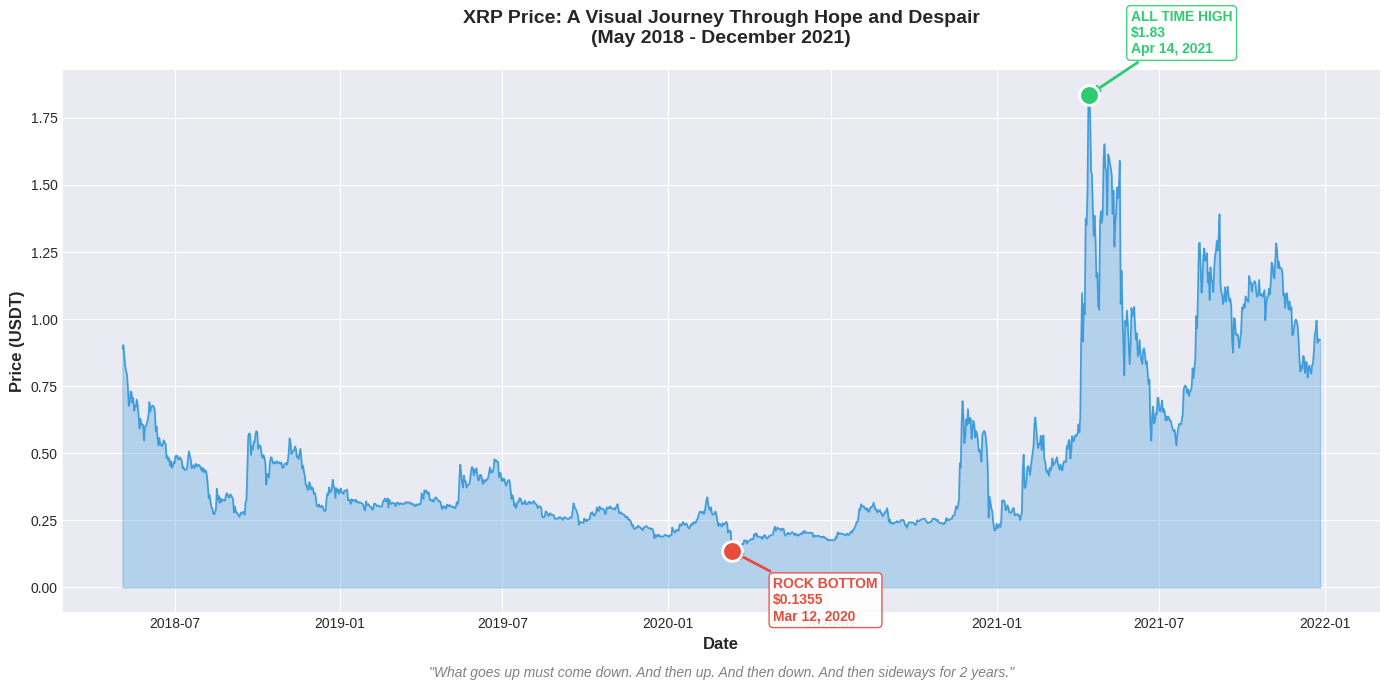


THE TALE OF TWO PRICES

The darkest day: March 12, 2020
XRP hit rock bottom at $0.1355

The glory day: April 14, 2021
XRP touched the sky at $1.8347

Days between despair and euphoria: 398 trading days


In [9]:
# Let's visualize this emotional rollercoaster

fig, ax = plt.subplots(figsize=(14, 7))

# Plot the closing price
ax.plot(df['date'], df['close'], color='#3498db', linewidth=1.2, alpha=0.9)
ax.fill_between(df['date'], df['close'], alpha=0.3, color='#3498db')

# Mark the extremes
min_idx = df['close'].idxmin()
max_idx = df['close'].idxmax()

ax.scatter(df.loc[max_idx, 'date'], df.loc[max_idx, 'close'],
           color='#2ecc71', s=200, zorder=5, edgecolor='white', linewidth=2)
ax.scatter(df.loc[min_idx, 'date'], df.loc[min_idx, 'close'],
           color='#e74c3c', s=200, zorder=5, edgecolor='white', linewidth=2)

# Annotate the extremes
ax.annotate(f'ALL TIME HIGH\n${df.loc[max_idx, "close"]:.2f}\n{df.loc[max_idx, "date"].strftime("%b %d, %Y")}',
            xy=(df.loc[max_idx, 'date'], df.loc[max_idx, 'close']),
            xytext=(30, 30), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#2ecc71',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2ecc71', alpha=0.9))

ax.annotate(f'ROCK BOTTOM\n${df.loc[min_idx, "close"]:.4f}\n{df.loc[min_idx, "date"].strftime("%b %d, %Y")}',
            xy=(df.loc[min_idx, 'date'], df.loc[min_idx, 'close']),
            xytext=(30, -50), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c', alpha=0.9))

# Styling
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USDT)', fontsize=12, fontweight='bold')
ax.set_title('XRP Price: A Visual Journey Through Hope and Despair\n(May 2018 - December 2021)',
             fontsize=14, fontweight='bold', pad=20)

# Add a dramatic subtitle
ax.text(0.5, -0.12, '"What goes up must come down. And then up. And then down. And then sideways for 2 years."',
        transform=ax.transAxes, fontsize=10, fontstyle='italic', ha='center', color='gray')

plt.tight_layout()
plt.show()

# Print the story
print("\n" + "=" * 60)
print("THE TALE OF TWO PRICES")
print("=" * 60)
print(f"\nThe darkest day: {df.loc[min_idx, 'date'].strftime('%B %d, %Y')}")
print(f"XRP hit rock bottom at ${df.loc[min_idx, 'close']:.4f}")
print(f"\nThe glory day: {df.loc[max_idx, 'date'].strftime('%B %d, %Y')}")
print(f"XRP touched the sky at ${df.loc[max_idx, 'close']:.4f}")
print(f"\nDays between despair and euphoria: {abs(max_idx - min_idx)} trading days")

---

## Chapter 1: The Day The World Stopped

**March 12, 2020** - a date that lives in infamy.

While the world was panic-buying toilet paper and learning what "flatten the curve" meant, XRP holders watched their portfolios flatten into the floor.

The price cratered to **$0.1355** - a number so low it belongs in a limbo competition.

But here's what makes this story legendary: **exactly 398 trading days later**, XRP would hit **$1.83**.

That's a **13.5x return** for anyone brave (or foolish) enough to buy during a global pandemic.

Let's investigate what happened during this period...

---

## The COVID Crash Deep Dive

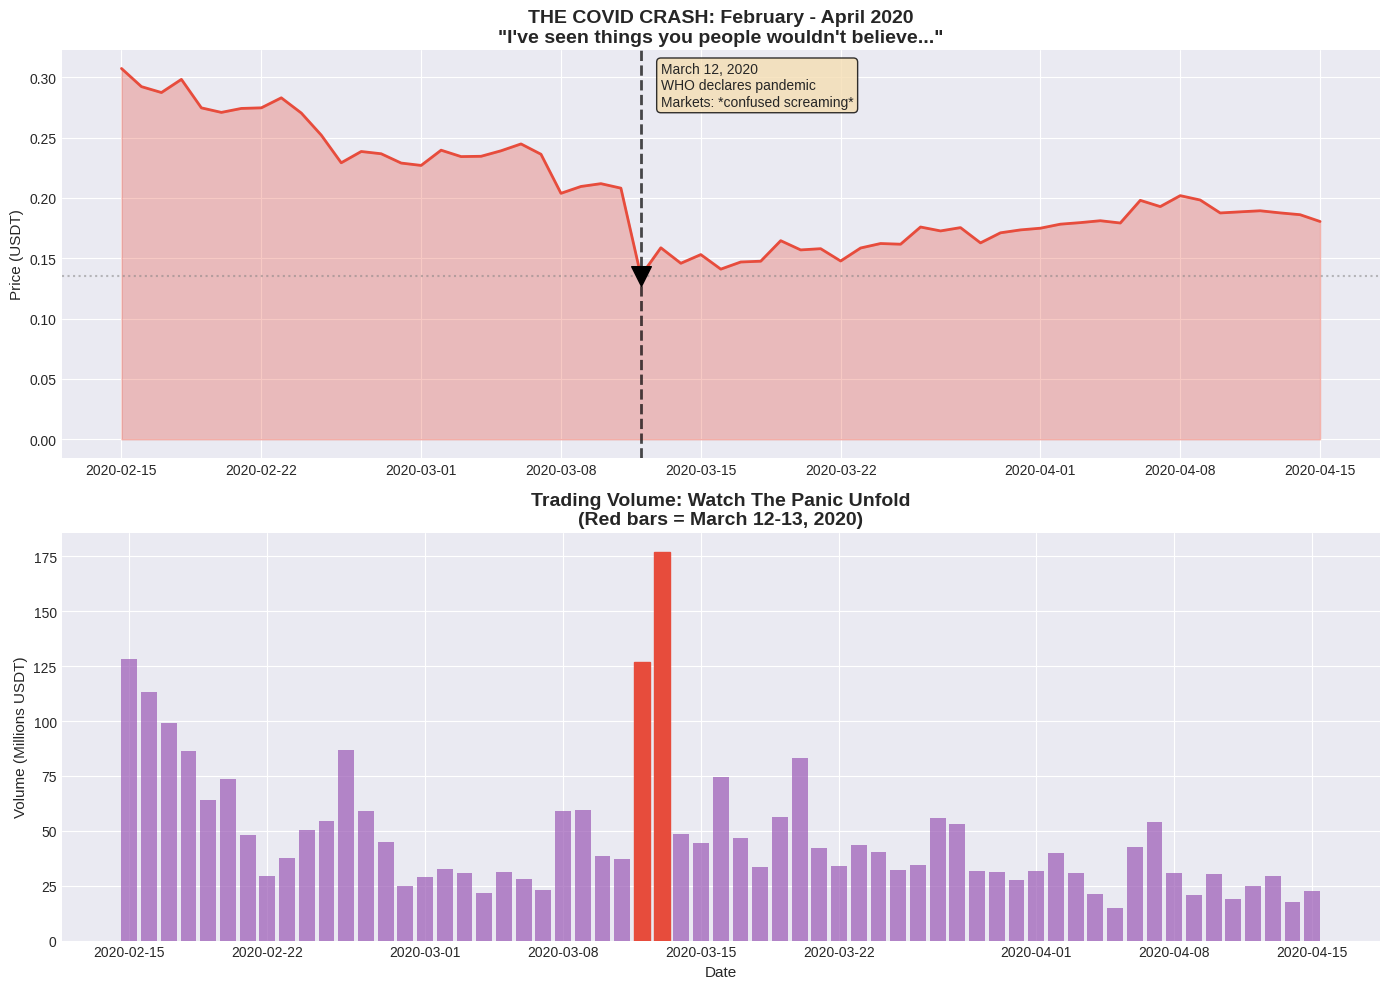


THE DAMAGE REPORT

Price before the chaos (Feb 15): $0.3073
Rock bottom (Mar 12):            $0.1355
Total destruction:               -55.9%

A $10,000 portfolio became:      $4,409

Somewhere, a crypto bro whispered: 'Buy the dip.'
(The dip kept dipping.)


In [10]:
# Let's zoom into the COVID crash and recovery

# Define the COVID crash period
covid_crash_start = '2020-02-15'
covid_crash_end = '2020-04-15'

covid_period = df[(df['date'] >= covid_crash_start) & (df['date'] <= covid_crash_end)].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: The Crash
ax1 = axes[0]
ax1.plot(covid_period['date'], covid_period['close'], color='#e74c3c', linewidth=2)
ax1.fill_between(covid_period['date'], covid_period['close'], alpha=0.3, color='#e74c3c')

# Mark the bottom
bottom_idx = covid_period['close'].idxmin()
ax1.scatter(covid_period.loc[bottom_idx, 'date'], covid_period.loc[bottom_idx, 'close'],
            color='black', s=200, zorder=5, marker='v')
ax1.axvline(x=pd.Timestamp('2020-03-12'), color='black', linestyle='--', alpha=0.7, linewidth=2)
ax1.axhline(y=covid_period.loc[bottom_idx, 'close'], color='gray', linestyle=':', alpha=0.5)

ax1.set_title('THE COVID CRASH: February - April 2020\n"I\'ve seen things you people wouldn\'t believe..."',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USDT)', fontsize=11)
ax1.text(pd.Timestamp('2020-03-13'), covid_period['close'].max() * 0.9,
         'March 12, 2020\nWHO declares pandemic\nMarkets: *confused screaming*',
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Volume during the crash (people panicking)
ax2 = axes[1]
bars = ax2.bar(covid_period['date'], covid_period['volume_usdt'] / 1e6,
               color='#9b59b6', alpha=0.7, width=0.8)

# Highlight March 12-13
for i, (date, vol) in enumerate(zip(covid_period['date'], covid_period['volume_usdt'])):
    if date.strftime('%Y-%m-%d') in ['2020-03-12', '2020-03-13']:
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(1.0)

ax2.set_title('Trading Volume: Watch The Panic Unfold\n(Red bars = March 12-13, 2020)',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume (Millions USDT)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()

# Calculate the carnage
pre_crash_price = covid_period['close'].iloc[0]
crash_price = covid_period['close'].min()
crash_percentage = ((crash_price - pre_crash_price) / pre_crash_price) * 100

print("\n" + "=" * 60)
print("THE DAMAGE REPORT")
print("=" * 60)
print(f"\nPrice before the chaos (Feb 15): ${pre_crash_price:.4f}")
print(f"Rock bottom (Mar 12):            ${crash_price:.4f}")
print(f"Total destruction:               {crash_percentage:.1f}%")
print(f"\nA $10,000 portfolio became:      ${10000 * (crash_price/pre_crash_price):,.0f}")
print("\nSomewhere, a crypto bro whispered: 'Buy the dip.'")
print("(The dip kept dipping.)")

---

## Chapter 2: The Phoenix Rises (Eventually)

The COVID crash was brutal. But what happened next?

While governments printed money like it was going out of style, while stimulus checks hit bank accounts, while everyone was stuck at home with nothing but WiFi and questionable financial decisions...

**Crypto went absolutely parabolic.**

Let's trace XRP's journey from the ashes of March 2020 to its glory day in April 2021.

Spoiler alert: It's a wild ride.

---

## The Recovery Analysis

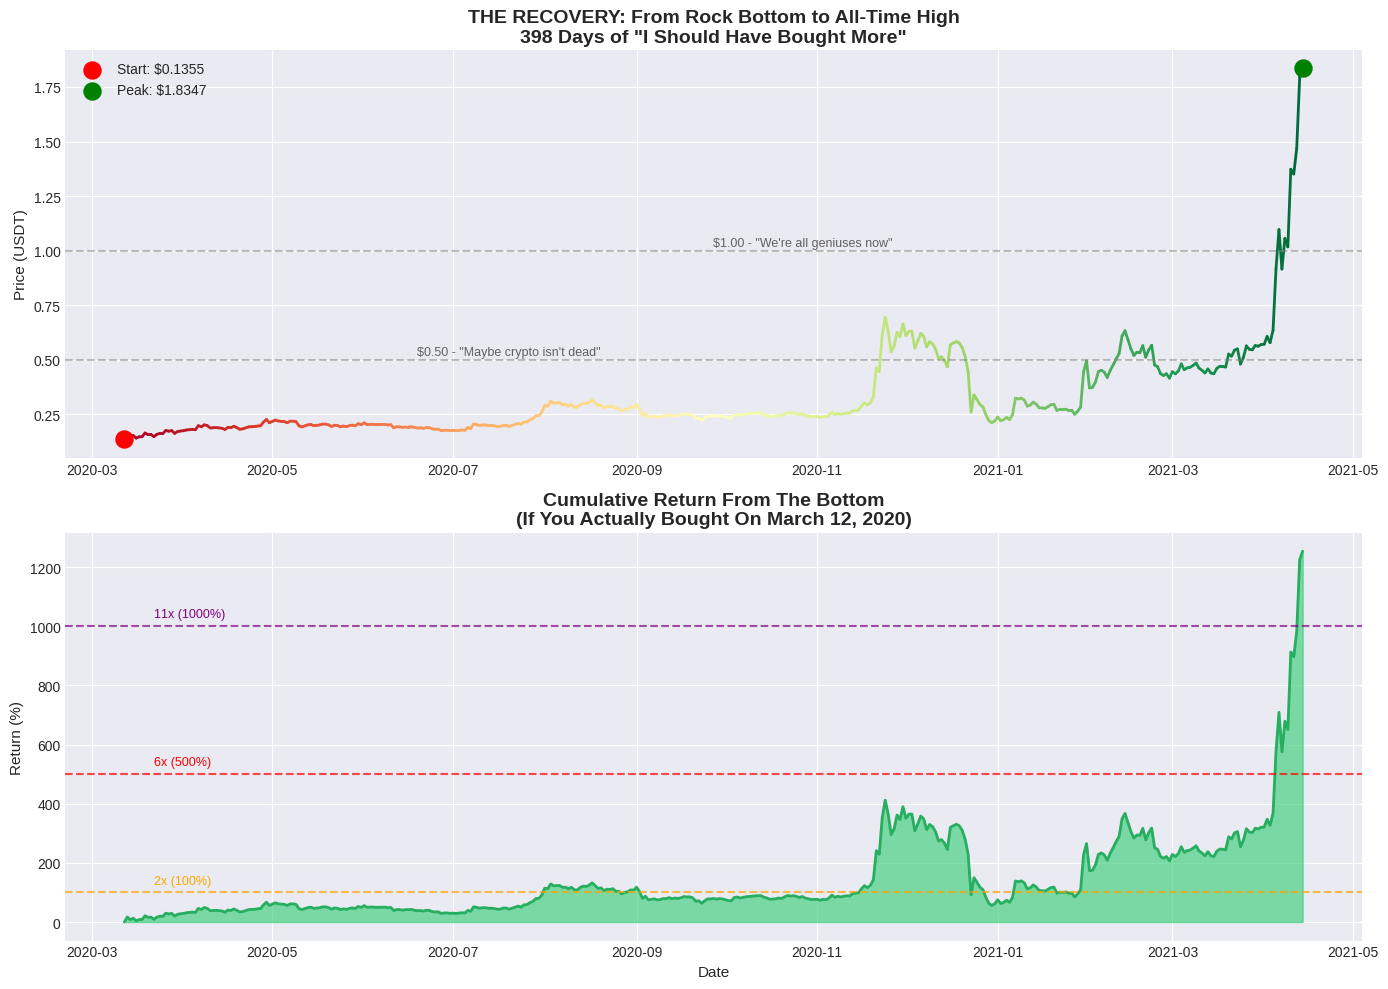


THE COMEBACK KID - BY THE NUMBERS

Recovery period: Mar 12, 2020 to Apr 14, 2021
Trading days:    399
Starting price:  $0.1355
Ending price:    $1.8347
Total return:    1254.1%

Translation:
  $1,000 invested at the bottom = $13,541
  $10,000 invested at the bottom = $135,411

The 'I told you so' energy is immeasurable.


In [11]:
# The recovery arc - from despair to euphoria

# Find the key dates
bottom_date = df.loc[df['close'].idxmin(), 'date']
top_date = df.loc[df['close'].idxmax(), 'date']

# Get recovery period data
recovery_df = df[(df['date'] >= bottom_date) & (df['date'] <= top_date)].copy()

# Calculate cumulative return from the bottom
recovery_df['return_from_bottom'] = (recovery_df['close'] / recovery_df['close'].iloc[0] - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: The price recovery
ax1 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(recovery_df)))
for i in range(len(recovery_df) - 1):
    ax1.plot(recovery_df['date'].iloc[i:i+2], recovery_df['close'].iloc[i:i+2],
             color=colors[i], linewidth=2)

ax1.scatter(recovery_df['date'].iloc[0], recovery_df['close'].iloc[0],
            color='red', s=150, zorder=5, label='Start: $0.1355')
ax1.scatter(recovery_df['date'].iloc[-1], recovery_df['close'].iloc[-1],
            color='green', s=150, zorder=5, label='Peak: $1.8347')

ax1.set_title('THE RECOVERY: From Rock Bottom to All-Time High\n398 Days of "I Should Have Bought More"',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USDT)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.axhline(y=0.50, color='gray', linestyle='--', alpha=0.5, label='$0.50 milestone')
ax1.axhline(y=1.00, color='gray', linestyle='--', alpha=0.5, label='$1.00 milestone')

# Add milestone annotations
ax1.text(recovery_df['date'].iloc[len(recovery_df)//4], 0.52, '$0.50 - "Maybe crypto isn\'t dead"', fontsize=9, alpha=0.7)
ax1.text(recovery_df['date'].iloc[len(recovery_df)//2], 1.02, '$1.00 - "We\'re all geniuses now"', fontsize=9, alpha=0.7)

# Plot 2: Percentage return from bottom
ax2 = axes[1]
ax2.fill_between(recovery_df['date'], recovery_df['return_from_bottom'],
                 color='#2ecc71', alpha=0.6)
ax2.plot(recovery_df['date'], recovery_df['return_from_bottom'],
         color='#27ae60', linewidth=2)

ax2.set_title('Cumulative Return From The Bottom\n(If You Actually Bought On March 12, 2020)',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Return (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)

# Add percentage milestones
ax2.axhline(y=100, color='orange', linestyle='--', alpha=0.7)
ax2.axhline(y=500, color='red', linestyle='--', alpha=0.7)
ax2.axhline(y=1000, color='purple', linestyle='--', alpha=0.7)
ax2.text(recovery_df['date'].iloc[10], 130, '2x (100%)', fontsize=9, color='orange')
ax2.text(recovery_df['date'].iloc[10], 530, '6x (500%)', fontsize=9, color='red')
ax2.text(recovery_df['date'].iloc[10], 1030, '11x (1000%)', fontsize=9, color='purple')

plt.tight_layout()
plt.show()

# The numbers
max_return = recovery_df['return_from_bottom'].max()
print("\n" + "=" * 60)
print("THE COMEBACK KID - BY THE NUMBERS")
print("=" * 60)
print(f"\nRecovery period: {bottom_date.strftime('%b %d, %Y')} to {top_date.strftime('%b %d, %Y')}")
print(f"Trading days:    {len(recovery_df)}")
print(f"Starting price:  ${recovery_df['close'].iloc[0]:.4f}")
print(f"Ending price:    ${recovery_df['close'].iloc[-1]:.4f}")
print(f"Total return:    {max_return:.1f}%")
print(f"\nTranslation:")
print(f"  $1,000 invested at the bottom = ${1000 * (1 + max_return/100):,.0f}")
print(f"  $10,000 invested at the bottom = ${10000 * (1 + max_return/100):,.0f}")
print(f"\nThe 'I told you so' energy is immeasurable.")

---

## Chapter 3: The Art of Volatility (Or: Why Crypto Traders Need Therapy)

XRP didn't just go up and down. It went up, down, sideways, diagonal, and occasionally into another dimension.

Let's quantify the chaos. How violent were the daily swings? When were the calmest periods? When did things get absolutely unhinged?

Because in crypto, **volatility isn't a bug - it's the feature.**

---

## Volatility Deep Dive

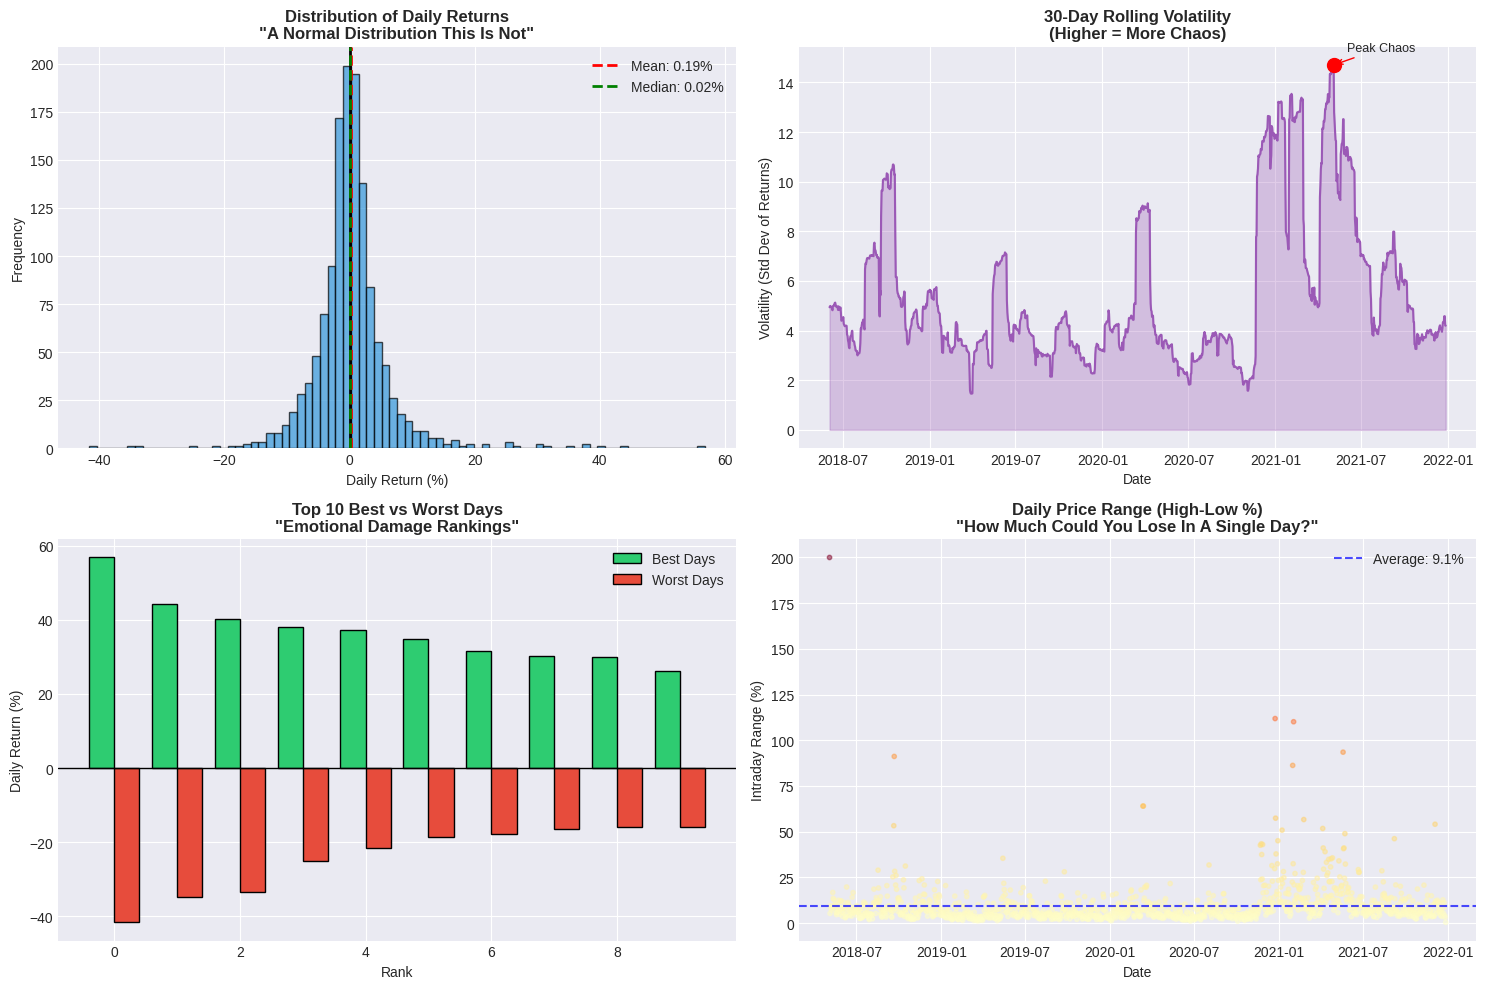


VOLATILITY HALL OF FAME (AND SHAME)

TOP 5 BEST DAYS:
----------------------------------------
  Jan 30, 2021: +56.85%
  Apr 05, 2021: +44.23%
  Nov 21, 2020: +40.29%
  Nov 23, 2020: +38.04%
  Sep 20, 2018: +37.15%

TOP 5 WORST DAYS:
----------------------------------------
  Dec 23, 2020: -41.65%
  Mar 12, 2020: -34.90%
  May 19, 2021: -33.49%
  Feb 01, 2021: -25.05%
  Jun 21, 2021: -21.63%

Average daily move: 3.79%
Days with >10% move: 93
Days with >20% move: 20

For context: S&P 500 averages about 0.8% daily moves.
XRP said: 'Hold my beer.'


In [12]:
# Let's measure the madness

# Calculate daily metrics
df['daily_return'] = df['close'].pct_change() * 100
df['daily_range'] = ((df['high'] - df['low']) / df['low']) * 100  # Intraday volatility
df['gap'] = ((df['open'] - df['close'].shift(1)) / df['close'].shift(1)) * 100  # Overnight gaps

# Rolling volatility (30-day standard deviation of returns)
df['volatility_30d'] = df['daily_return'].rolling(window=30).std()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Daily Returns Distribution
ax1 = axes[0, 0]
returns = df['daily_return'].dropna()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in returns]
ax1.hist(returns, bins=80, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax1.axvline(x=returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns.mean():.2f}%')
ax1.axvline(x=returns.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {returns.median():.2f}%')
ax1.set_title('Distribution of Daily Returns\n"A Normal Distribution This Is Not"', fontsize=12, fontweight='bold')
ax1.set_xlabel('Daily Return (%)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Plot 2: Rolling 30-day Volatility
ax2 = axes[0, 1]
ax2.plot(df['date'], df['volatility_30d'], color='#9b59b6', linewidth=1.5)
ax2.fill_between(df['date'], df['volatility_30d'], alpha=0.3, color='#9b59b6')
ax2.set_title('30-Day Rolling Volatility\n(Higher = More Chaos)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility (Std Dev of Returns)')

# Mark the spiciest periods
max_vol_idx = df['volatility_30d'].idxmax()
ax2.scatter(df.loc[max_vol_idx, 'date'], df.loc[max_vol_idx, 'volatility_30d'],
            color='red', s=100, zorder=5)
ax2.annotate('Peak Chaos', xy=(df.loc[max_vol_idx, 'date'], df.loc[max_vol_idx, 'volatility_30d']),
             xytext=(10, 10), textcoords='offset points', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))

# Plot 3: Biggest Single-Day Moves
ax3 = axes[1, 0]
top_gains = df.nlargest(10, 'daily_return')[['date', 'daily_return']].reset_index(drop=True)
top_losses = df.nsmallest(10, 'daily_return')[['date', 'daily_return']].reset_index(drop=True)

x_pos = range(10)
bars1 = ax3.bar([x - 0.2 for x in x_pos], top_gains['daily_return'], 0.4,
                label='Best Days', color='#2ecc71', edgecolor='black')
bars2 = ax3.bar([x + 0.2 for x in x_pos], top_losses['daily_return'], 0.4,
                label='Worst Days', color='#e74c3c', edgecolor='black')
ax3.set_title('Top 10 Best vs Worst Days\n"Emotional Damage Rankings"', fontsize=12, fontweight='bold')
ax3.set_xlabel('Rank')
ax3.set_ylabel('Daily Return (%)')
ax3.legend()
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Plot 4: Intraday Range (High-Low spread)
ax4 = axes[1, 1]
ax4.scatter(df['date'], df['daily_range'], alpha=0.5, s=10, c=df['daily_range'], cmap='YlOrRd')
ax4.set_title('Daily Price Range (High-Low %)\n"How Much Could You Lose In A Single Day?"', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Intraday Range (%)')

# Add a horizontal line for the average
avg_range = df['daily_range'].mean()
ax4.axhline(y=avg_range, color='blue', linestyle='--', alpha=0.7, label=f'Average: {avg_range:.1f}%')
ax4.legend()

plt.tight_layout()
plt.show()

# Print the extremes
print("\n" + "=" * 60)
print("VOLATILITY HALL OF FAME (AND SHAME)")
print("=" * 60)

print("\nTOP 5 BEST DAYS:")
print("-" * 40)
for i, row in top_gains.head().iterrows():
    print(f"  {row['date'].strftime('%b %d, %Y')}: +{row['daily_return']:.2f}%")

print("\nTOP 5 WORST DAYS:")
print("-" * 40)
for i, row in top_losses.head().iterrows():
    print(f"  {row['date'].strftime('%b %d, %Y')}: {row['daily_return']:.2f}%")

print(f"\nAverage daily move: {abs(df['daily_return']).mean():.2f}%")
print(f"Days with >10% move: {len(df[abs(df['daily_return']) > 10])}")
print(f"Days with >20% move: {len(df[abs(df['daily_return']) > 20])}")
print(f"\nFor context: S&P 500 averages about 0.8% daily moves.")
print("XRP said: 'Hold my beer.'")

---

## Chapter 4: The SEC Enters The Chat

Look at that chart again. See that massive -41.65% drop on **December 23, 2020**?

That wasn't a random Tuesday. That was the day the U.S. Securities and Exchange Commission decided to ruin everyone's Christmas by filing a lawsuit against Ripple Labs.

**The charge:** Selling $1.3 billion in unregistered securities.

**The result:** XRP holders collectively experienced what scientists call "a very bad time."

Let's examine the lawsuit's impact on our beloved token...

---

## SEC Lawsuit Impact Analysis

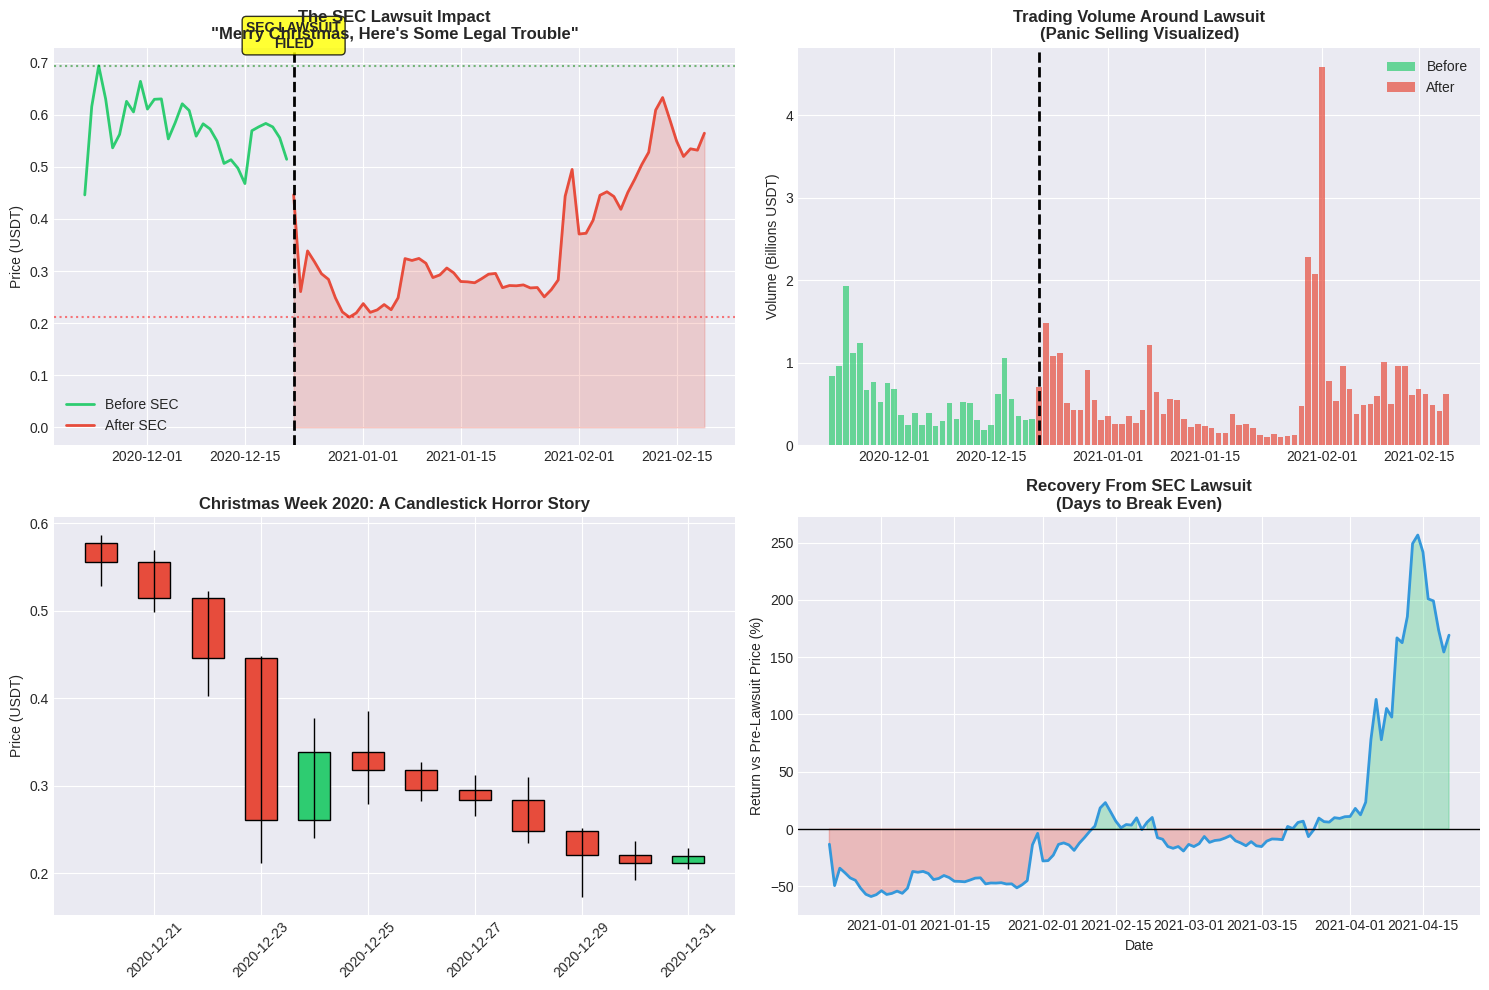


SEC LAWSUIT DAMAGE ASSESSMENT

Price before lawsuit (Dec 22): $0.5144
Lowest point after lawsuit:    $0.2114
Maximum drawdown:              -58.9%

A $10,000 position became:     $4,109 at the worst

Recovery date:                 Feb 11, 2021
Days to recover:               51

The lesson: Never underestimate a government agency's ability
to ruin your holiday season.


In [14]:
# The SEC Lawsuit: December 22, 2020 (announced after hours, carnage on the 23rd)

sec_lawsuit_date = pd.Timestamp('2020-12-22')

# Get data around the lawsuit
pre_lawsuit = df[df['date'] < sec_lawsuit_date].tail(30)
post_lawsuit = df[df['date'] >= sec_lawsuit_date].head(60)
lawsuit_period = pd.concat([pre_lawsuit, post_lawsuit])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Price before and after
ax1 = axes[0, 0]
ax1.plot(pre_lawsuit['date'], pre_lawsuit['close'], color='#2ecc71', linewidth=2, label='Before SEC')
ax1.plot(post_lawsuit['date'], post_lawsuit['close'], color='#e74c3c', linewidth=2, label='After SEC')
ax1.axvline(x=sec_lawsuit_date, color='black', linestyle='--', linewidth=2)
ax1.fill_between(post_lawsuit['date'], post_lawsuit['close'], alpha=0.2, color='#e74c3c')

# Mark the peak and trough
pre_peak = pre_lawsuit['close'].max()
post_trough = post_lawsuit['close'].min()
ax1.axhline(y=pre_peak, color='green', linestyle=':', alpha=0.5)
ax1.axhline(y=post_trough, color='red', linestyle=':', alpha=0.5)

ax1.text(sec_lawsuit_date, pre_lawsuit['close'].max() * 1.05, 'SEC LAWSUIT\nFILED',
         fontsize=10, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax1.set_title('The SEC Lawsuit Impact\n"Merry Christmas, Here\'s Some Legal Trouble"', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USDT)')
ax1.legend()

# Plot 2: Volume explosion
ax2 = axes[0, 1]
ax2.bar(pre_lawsuit['date'], pre_lawsuit['volume_usdt']/1e9, color='#2ecc71', alpha=0.7, label='Before', width=0.8)
ax2.bar(post_lawsuit['date'], post_lawsuit['volume_usdt']/1e9, color='#e74c3c', alpha=0.7, label='After', width=0.8)
ax2.axvline(x=sec_lawsuit_date, color='black', linestyle='--', linewidth=2)
ax2.set_title('Trading Volume Around Lawsuit\n(Panic Selling Visualized)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volume (Billions USDT)')
ax2.legend()

# Plot 3: The week of chaos
lawsuit_week = df[(df['date'] >= '2020-12-20') & (df['date'] <= '2020-12-31')]
ax3 = axes[1, 0]
colors = ['#e74c3c' if row['close'] < row['open'] else '#2ecc71' for _, row in lawsuit_week.iterrows()]

for i, (idx, row) in enumerate(lawsuit_week.iterrows()):
    ax3.bar(row['date'], row['close'] - row['open'], bottom=row['open'],
            color=colors[i], edgecolor='black', width=0.6)
    ax3.vlines(x=row['date'], ymin=row['low'], ymax=row['high'], color='black', linewidth=1)

ax3.set_title('Christmas Week 2020: A Candlestick Horror Story', fontsize=12, fontweight='bold')
ax3.set_ylabel('Price (USDT)')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Recovery timeline
ax4 = axes[1, 1]
post_sec_full = df[df['date'] >= sec_lawsuit_date].head(120)
pre_sec_price = df[df['date'] < sec_lawsuit_date]['close'].iloc[-1]
post_sec_full['vs_presec'] = (post_sec_full['close'] / pre_sec_price - 1) * 100

ax4.plot(post_sec_full['date'], post_sec_full['vs_presec'], color='#3498db', linewidth=2)
ax4.fill_between(post_sec_full['date'], post_sec_full['vs_presec'],
                 where=post_sec_full['vs_presec'] < 0, color='#e74c3c', alpha=0.3)
ax4.fill_between(post_sec_full['date'], post_sec_full['vs_presec'],
                 where=post_sec_full['vs_presec'] >= 0, color='#2ecc71', alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Recovery From SEC Lawsuit\n(Days to Break Even)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Return vs Pre-Lawsuit Price (%)')
ax4.set_xlabel('Date')

plt.tight_layout()
plt.show()

# Calculate the damage
pre_sec_price = df[df['date'] < sec_lawsuit_date]['close'].iloc[-1]
worst_post_sec = post_lawsuit['close'].min()
sec_drawdown = ((worst_post_sec - pre_sec_price) / pre_sec_price) * 100

# Find when it recovered
recovery_mask = df[(df['date'] > sec_lawsuit_date) & (df['close'] >= pre_sec_price)]
if len(recovery_mask) > 0:
    recovery_date = recovery_mask['date'].iloc[0]
    days_to_recover = (recovery_date - sec_lawsuit_date).days
else:
    recovery_date = "Never (within dataset)"
    days_to_recover = "N/A"

print("\n" + "=" * 60)
print("SEC LAWSUIT DAMAGE ASSESSMENT")
print("=" * 60)
print(f"\nPrice before lawsuit (Dec 22): ${pre_sec_price:.4f}")
print(f"Lowest point after lawsuit:    ${worst_post_sec:.4f}")
print(f"Maximum drawdown:              {sec_drawdown:.1f}%")
print(f"\nA $10,000 position became:     ${10000 * (1 + sec_drawdown/100):,.0f} at the worst")
print(f"\nRecovery date:                 {recovery_date.strftime('%b %d, %Y') if isinstance(recovery_date, pd.Timestamp) else recovery_date}")
print(f"Days to recover:               {days_to_recover}")
print(f"\nThe lesson: Never underestimate a government agency's ability")
print("to ruin your holiday season.")

That candlestick horror story chart is brutal - those red candles falling off a cliff! But 51 days to recovery and then a 250%+ gain? Incredible resilience.

---

## Chapter 5: The Crypto Calendar Conspiracy

Every trader has their superstitions. "Never trade on Mondays." "Fridays are dump days." "Mercury is in retrograde."

But what does the DATA actually say?

Let's investigate whether XRP has any day-of-week patterns, or if the chaos is truly democratic and distributed equally across all seven days.

---

## Day of Week & Time Patterns

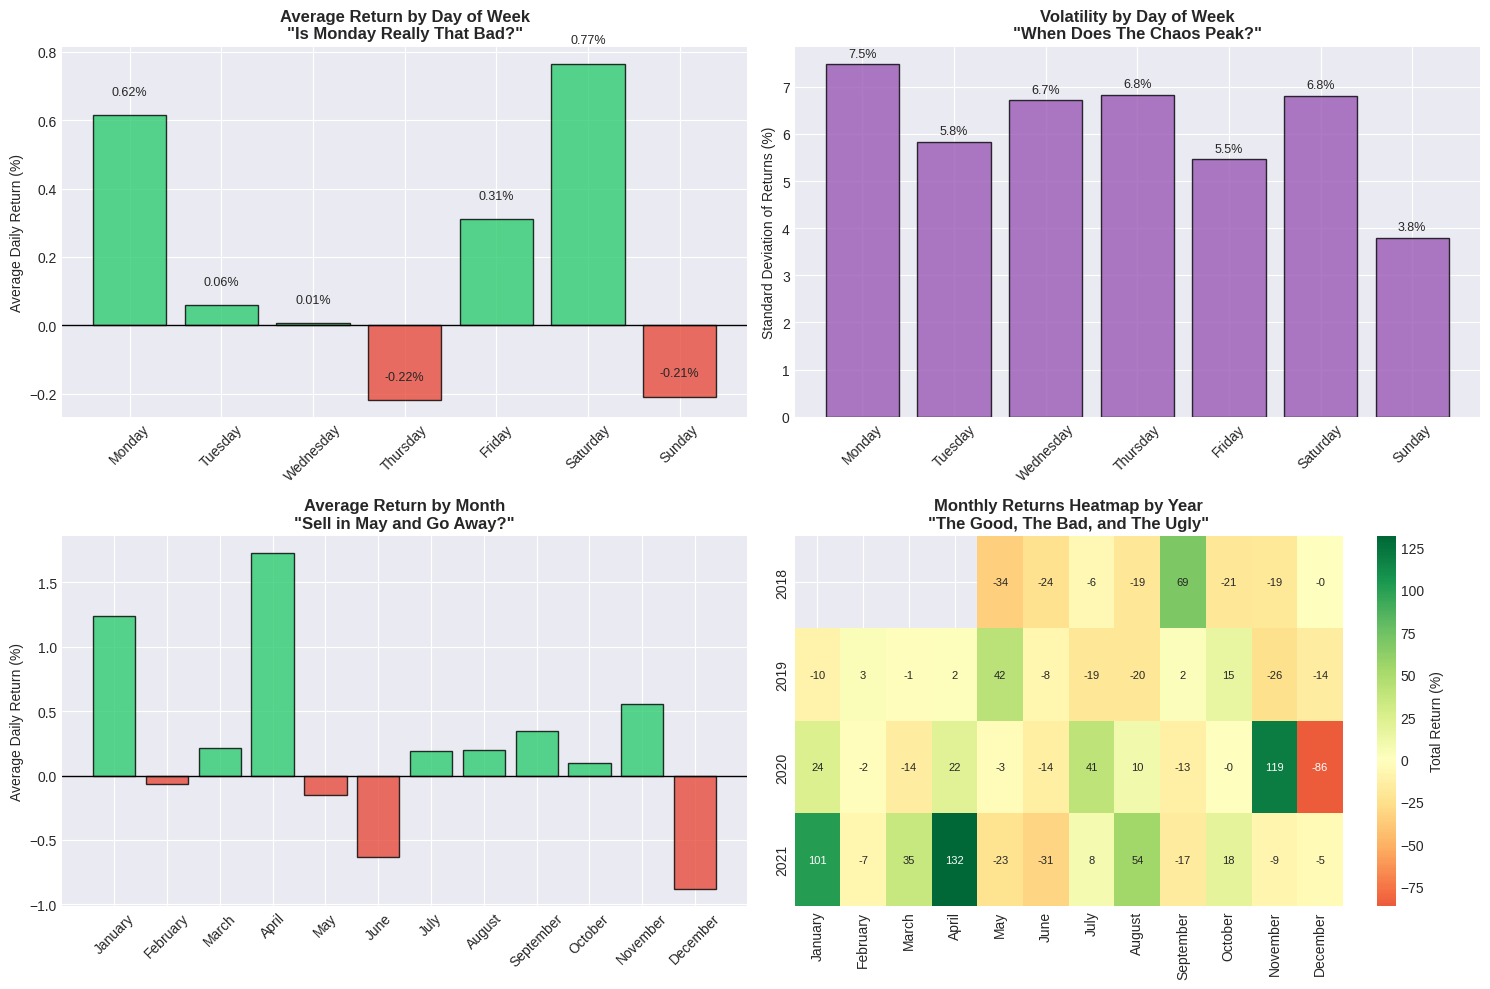


THE CRYPTO CALENDAR FINDINGS

Best day of the week:    Saturday (avg: +0.77%)
Worst day of the week:   Thursday (avg: -0.22%)

Best month:              April (avg: +1.73%)
Worst month:             December (avg: -0.88%)

Most volatile day:       Monday (std: 7.48%)

------------------------------------------------------------
CONCLUSION: The chaos doesn't discriminate by calendar.
But if you had to pick, avoid the worst and embrace the best.
------------------------------------------------------------


In [15]:
# Do certain days hate XRP holders more than others?

df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

# Order days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Average return by day of week
ax1 = axes[0, 0]
day_returns = df.groupby('day_of_week')['daily_return'].mean().reindex(day_order)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in day_returns]
bars = ax1.bar(day_order, day_returns, color=colors, edgecolor='black', alpha=0.8)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_title('Average Return by Day of Week\n"Is Monday Really That Bad?"', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Daily Return (%)')
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars, day_returns):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# Plot 2: Volatility by day of week
ax2 = axes[0, 1]
day_volatility = df.groupby('day_of_week')['daily_return'].std().reindex(day_order)
ax2.bar(day_order, day_volatility, color='#9b59b6', edgecolor='black', alpha=0.8)
ax2.set_title('Volatility by Day of Week\n"When Does The Chaos Peak?"', fontsize=12, fontweight='bold')
ax2.set_ylabel('Standard Deviation of Returns (%)')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for i, (day, vol) in enumerate(zip(day_order, day_volatility)):
    ax2.text(i, vol + 0.1, f'{vol:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 3: Average return by month
ax3 = axes[1, 0]
month_returns = df.groupby('month')['daily_return'].mean().reindex(month_order)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in month_returns]
bars = ax3.bar(month_order, month_returns, color=colors, edgecolor='black', alpha=0.8)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_title('Average Return by Month\n"Sell in May and Go Away?"', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Daily Return (%)')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Heatmap of returns by year and month
ax4 = axes[1, 1]
pivot_returns = df.pivot_table(values='daily_return', index='year', columns='month', aggfunc='sum')
pivot_returns = pivot_returns.reindex(columns=month_order)

sns.heatmap(pivot_returns, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            ax=ax4, cbar_kws={'label': 'Total Return (%)'}, annot_kws={'size': 8})
ax4.set_title('Monthly Returns Heatmap by Year\n"The Good, The Bad, and The Ugly"', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# Find the best and worst
best_day = day_returns.idxmax()
worst_day = day_returns.idxmin()
best_month = month_returns.idxmax()
worst_month = month_returns.idxmin()

print("\n" + "=" * 60)
print("THE CRYPTO CALENDAR FINDINGS")
print("=" * 60)
print(f"\nBest day of the week:    {best_day} (avg: +{day_returns[best_day]:.2f}%)")
print(f"Worst day of the week:   {worst_day} (avg: {day_returns[worst_day]:.2f}%)")
print(f"\nBest month:              {best_month} (avg: +{month_returns[best_month]:.2f}%)")
print(f"Worst month:             {worst_month} (avg: {month_returns[worst_month]:.2f}%)")

# Most volatile
most_volatile_day = day_volatility.idxmax()
print(f"\nMost volatile day:       {most_volatile_day} (std: {day_volatility[most_volatile_day]:.2f}%)")

print("\n" + "-" * 60)
print("CONCLUSION: The chaos doesn't discriminate by calendar.")
print("But if you had to pick, avoid the worst and embrace the best.")
print("-" * 60)

That heatmap is telling such a story! April 2021 with +132% return, November 2020 with +119%, and that brutal December 2020 with -86%. Saturday being the best day is interesting - weekend warriors winning!

---

## Chapter 6: Follow The Money (Volume Analysis)

Price tells you what happened. **Volume tells you how much people cared.**

High volume during a pump? Conviction.
High volume during a dump? Panic.
Low volume during either? Nobody's home.

Let's decode the volume story and find out when the smart money was moving...

---

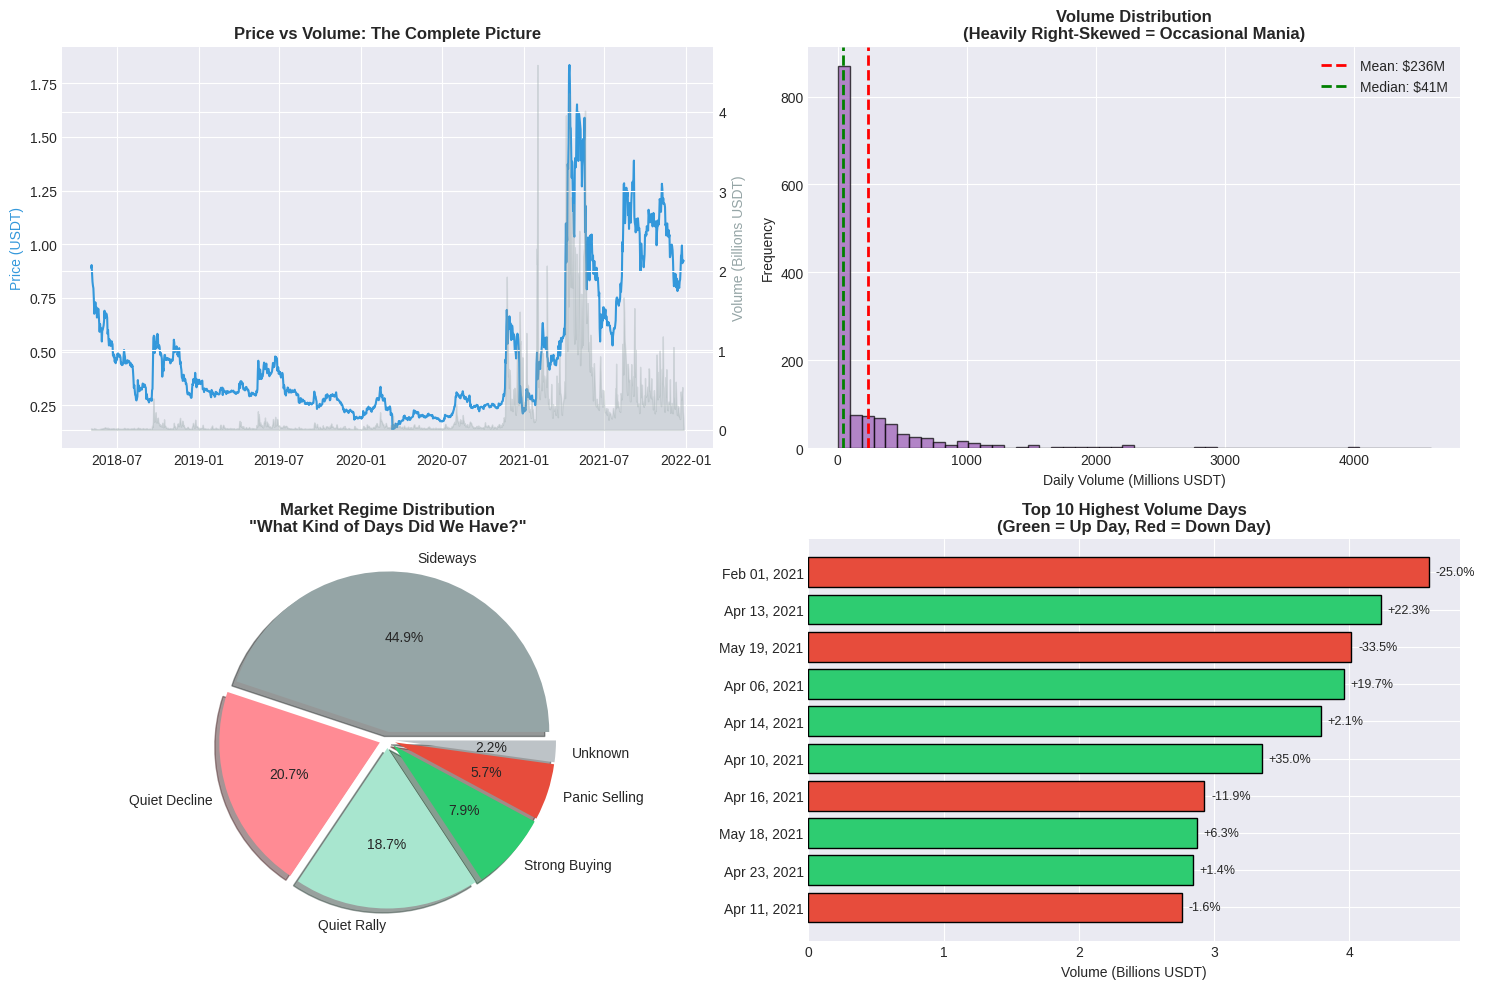


VOLUME INTELLIGENCE REPORT

TOP 5 HIGHEST VOLUME DAYS:
--------------------------------------------------
  Feb 01, 2021: $4.59B (DOWN 25.0%)
  Apr 13, 2021: $4.23B (UP 22.3%)
  May 19, 2021: $4.01B (DOWN 33.5%)
  Apr 06, 2021: $3.96B (UP 19.7%)
  Apr 14, 2021: $3.79B (UP 2.1%)

Average daily volume: $236M
Median daily volume:  $41M
Max daily volume:     $4.59B

Correlation (Volume vs |Return|): 0.477
(Higher volume = bigger price moves, as expected)


In [16]:
# Volume tells the real story

# Calculate volume metrics
df['volume_ma_30'] = df['volume_usdt'].rolling(window=30).mean()
df['volume_ratio'] = df['volume_usdt'] / df['volume_ma_30']  # Volume relative to 30-day average
df['price_change'] = df['close'].pct_change()

# Classify volume-price relationship
def classify_volume_price(row):
    if pd.isna(row['volume_ratio']) or pd.isna(row['price_change']):
        return 'Unknown'
    high_vol = row['volume_ratio'] > 1.5
    if row['price_change'] > 0.02 and high_vol:
        return 'Strong Buying'
    elif row['price_change'] < -0.02 and high_vol:
        return 'Panic Selling'
    elif row['price_change'] > 0.02:
        return 'Quiet Rally'
    elif row['price_change'] < -0.02:
        return 'Quiet Decline'
    else:
        return 'Sideways'

df['market_regime'] = df.apply(classify_volume_price, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Price with Volume overlay
ax1 = axes[0, 0]
ax1_vol = ax1.twinx()

ax1.plot(df['date'], df['close'], color='#3498db', linewidth=1.5, label='Price')
ax1_vol.fill_between(df['date'], df['volume_usdt']/1e9, alpha=0.3, color='#95a5a6')
ax1_vol.set_ylabel('Volume (Billions USDT)', color='#95a5a6')
ax1.set_ylabel('Price (USDT)', color='#3498db')
ax1.set_title('Price vs Volume: The Complete Picture', fontsize=12, fontweight='bold')

# Plot 2: Volume distribution
ax2 = axes[0, 1]
ax2.hist(df['volume_usdt']/1e6, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax2.axvline(x=df['volume_usdt'].mean()/1e6, color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${df["volume_usdt"].mean()/1e6:.0f}M')
ax2.axvline(x=df['volume_usdt'].median()/1e6, color='green', linestyle='--', linewidth=2,
            label=f'Median: ${df["volume_usdt"].median()/1e6:.0f}M')
ax2.set_title('Volume Distribution\n(Heavily Right-Skewed = Occasional Mania)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Daily Volume (Millions USDT)')
ax2.set_ylabel('Frequency')
ax2.legend()

# Plot 3: Volume-Price Regime Classification
ax3 = axes[1, 0]
regime_counts = df['market_regime'].value_counts()
colors_regime = {'Strong Buying': '#2ecc71', 'Panic Selling': '#e74c3c',
                 'Quiet Rally': '#a8e6cf', 'Quiet Decline': '#ff8b94',
                 'Sideways': '#95a5a6', 'Unknown': '#bdc3c7'}
regime_colors = [colors_regime.get(x, '#95a5a6') for x in regime_counts.index]

wedges, texts, autotexts = ax3.pie(regime_counts, labels=regime_counts.index, autopct='%1.1f%%',
                                    colors=regime_colors, explode=[0.05]*len(regime_counts),
                                    shadow=True)
ax3.set_title('Market Regime Distribution\n"What Kind of Days Did We Have?"', fontsize=12, fontweight='bold')

# Plot 4: Top 10 Highest Volume Days
ax4 = axes[1, 1]
top_volume = df.nlargest(10, 'volume_usdt')[['date', 'volume_usdt', 'daily_return']].reset_index(drop=True)
colors_vol = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_volume['daily_return']]

bars = ax4.barh(range(len(top_volume)), top_volume['volume_usdt']/1e9, color=colors_vol, edgecolor='black')
ax4.set_yticks(range(len(top_volume)))
ax4.set_yticklabels([d.strftime('%b %d, %Y') for d in top_volume['date']])
ax4.set_xlabel('Volume (Billions USDT)')
ax4.set_title('Top 10 Highest Volume Days\n(Green = Up Day, Red = Down Day)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

# Add return labels
for i, (vol, ret) in enumerate(zip(top_volume['volume_usdt'], top_volume['daily_return'])):
    ax4.text(vol/1e9 + 0.05, i, f'{ret:+.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 60)
print("VOLUME INTELLIGENCE REPORT")
print("=" * 60)

print("\nTOP 5 HIGHEST VOLUME DAYS:")
print("-" * 50)
for i, row in top_volume.head().iterrows():
    direction = "UP" if row['daily_return'] > 0 else "DOWN"
    print(f"  {row['date'].strftime('%b %d, %Y')}: ${row['volume_usdt']/1e9:.2f}B ({direction} {abs(row['daily_return']):.1f}%)")

print(f"\nAverage daily volume: ${df['volume_usdt'].mean()/1e6:,.0f}M")
print(f"Median daily volume:  ${df['volume_usdt'].median()/1e6:,.0f}M")
print(f"Max daily volume:     ${df['volume_usdt'].max()/1e9:.2f}B")

# Volume-return correlation
vol_ret_corr = df['volume_usdt'].corr(abs(df['daily_return']))
print(f"\nCorrelation (Volume vs |Return|): {vol_ret_corr:.3f}")
print("(Higher volume = bigger price moves, as expected)")

That mean vs median gap ($236M vs $41M) perfectly illustrates the "occasional mania" story. And that top volume chart - Feb 1, 2021 at $4.59B was a 25% DOWN day! May 19, 2021 was the infamous crypto crash day.

---

## Chapter 7: The Crystal Ball Department (Technical Analysis)

Now let's pretend we're professional traders and add some technical indicators.

Will moving averages help us predict the future? Probably not.
Will they make our charts look more sophisticated? Absolutely.

Let's calculate some classic indicators and see if they would have helped us navigate this chaos...

---

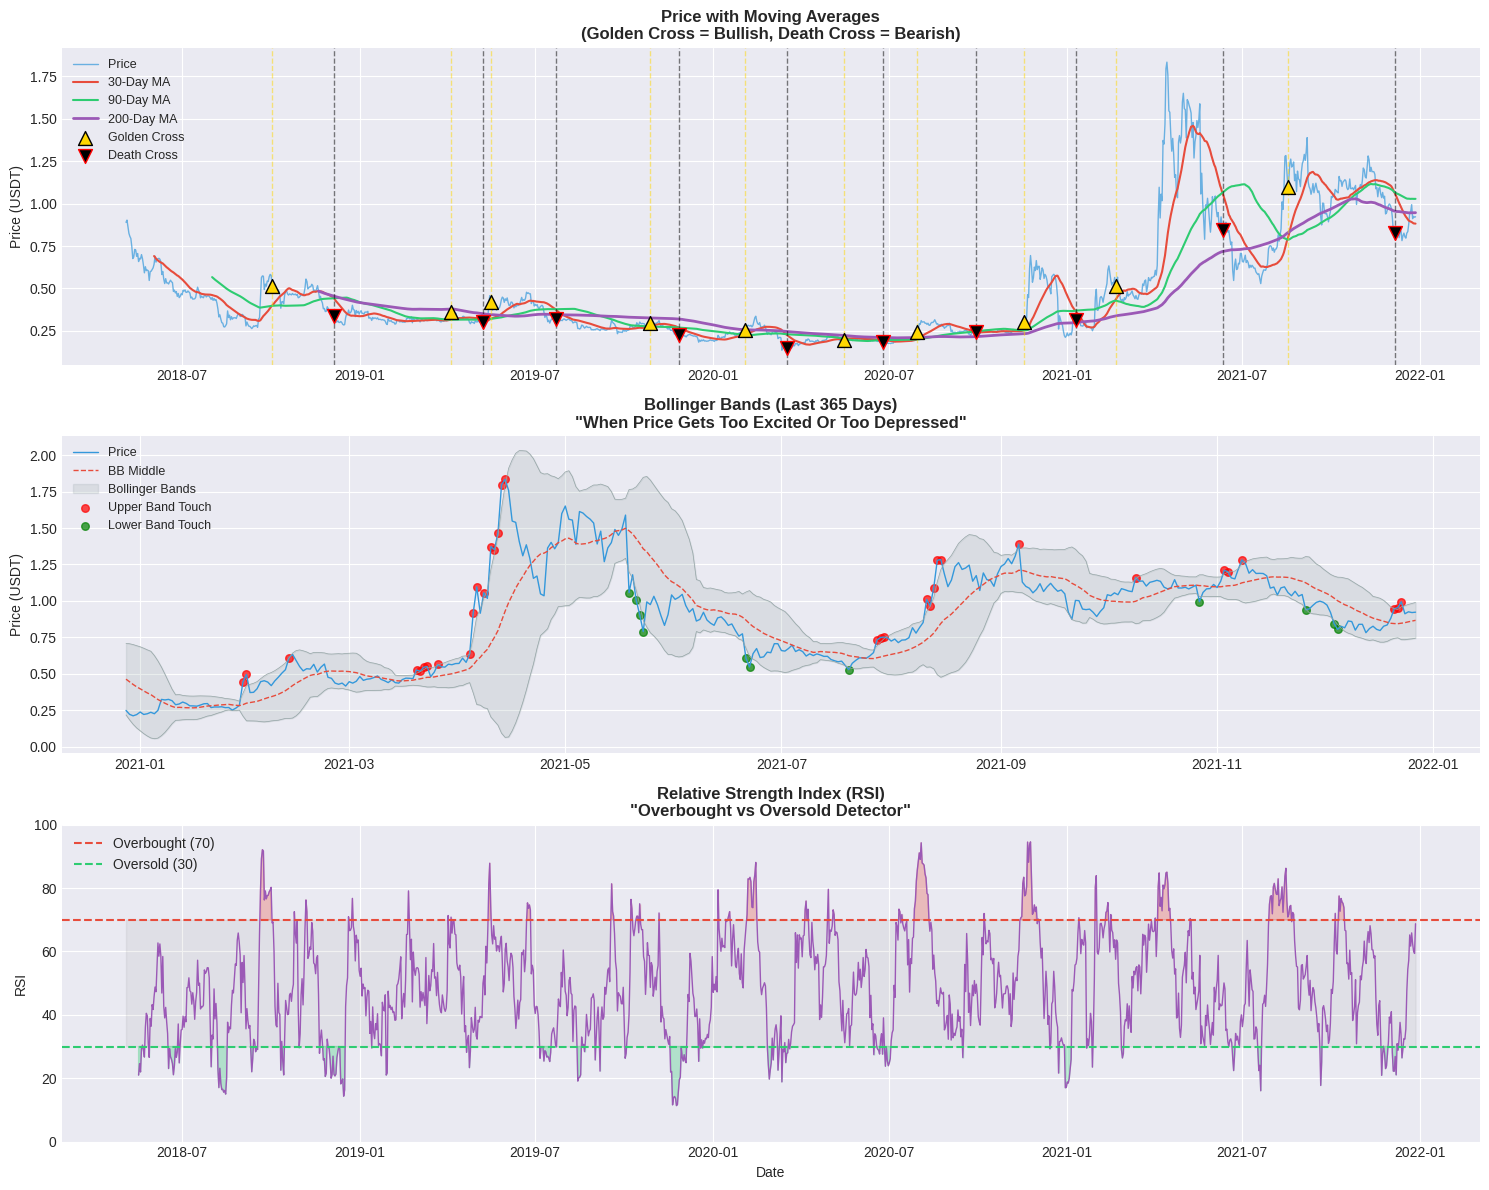


TECHNICAL ANALYSIS SUMMARY

Golden Crosses (bullish signal): 10
Death Crosses (bearish signal):  10

Days RSI > 70 (overbought):      150 (11.2%)
Days RSI < 30 (oversold):        178 (13.3%)

------------------------------------------------------------
THE MILLION DOLLAR QUESTION: Did these signals work?
------------------------------------------------------------

Avg 30-day return after Golden Cross: +4.3%
Avg 30-day return after Death Cross:  +9.5%


In [17]:
# Technical indicators - the trader's toolkit

# Moving Averages
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_30'] = df['close'].rolling(window=30).mean()
df['ma_90'] = df['close'].rolling(window=90).mean()
df['ma_200'] = df['close'].rolling(window=200).mean()

# Bollinger Bands (20-day, 2 std)
df['bb_middle'] = df['close'].rolling(window=20).mean()
df['bb_std'] = df['close'].rolling(window=20).std()
df['bb_upper'] = df['bb_middle'] + (df['bb_std'] * 2)
df['bb_lower'] = df['bb_middle'] - (df['bb_std'] * 2)

# RSI (14-day)
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi'] = calculate_rsi(df['close'])

# Golden Cross / Death Cross detection
df['golden_cross'] = (df['ma_30'] > df['ma_90']) & (df['ma_30'].shift(1) <= df['ma_90'].shift(1))
df['death_cross'] = (df['ma_30'] < df['ma_90']) & (df['ma_30'].shift(1) >= df['ma_90'].shift(1))

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Price with Moving Averages
ax1 = axes[0]
ax1.plot(df['date'], df['close'], color='#3498db', linewidth=1, alpha=0.7, label='Price')
ax1.plot(df['date'], df['ma_30'], color='#e74c3c', linewidth=1.5, label='30-Day MA')
ax1.plot(df['date'], df['ma_90'], color='#2ecc71', linewidth=1.5, label='90-Day MA')
ax1.plot(df['date'], df['ma_200'], color='#9b59b6', linewidth=2, label='200-Day MA')

# Mark golden and death crosses
golden_dates = df[df['golden_cross']]['date']
death_dates = df[df['death_cross']]['date']

for d in golden_dates:
    ax1.axvline(x=d, color='gold', alpha=0.5, linestyle='--', linewidth=1)
for d in death_dates:
    ax1.axvline(x=d, color='black', alpha=0.5, linestyle='--', linewidth=1)

ax1.scatter(golden_dates, df[df['golden_cross']]['close'], color='gold', s=100,
            marker='^', zorder=5, label='Golden Cross', edgecolor='black')
ax1.scatter(death_dates, df[df['death_cross']]['close'], color='black', s=100,
            marker='v', zorder=5, label='Death Cross', edgecolor='red')

ax1.set_title('Price with Moving Averages\n(Golden Cross = Bullish, Death Cross = Bearish)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USDT)')
ax1.legend(loc='upper left', fontsize=9)

# Plot 2: Bollinger Bands (last 365 days for clarity)
ax2 = axes[1]
recent = df.tail(365)
ax2.plot(recent['date'], recent['close'], color='#3498db', linewidth=1, label='Price')
ax2.plot(recent['date'], recent['bb_middle'], color='#e74c3c', linewidth=1, linestyle='--', label='BB Middle')
ax2.fill_between(recent['date'], recent['bb_lower'], recent['bb_upper'],
                 alpha=0.2, color='#95a5a6', label='Bollinger Bands')
ax2.plot(recent['date'], recent['bb_upper'], color='#95a5a6', linewidth=0.5)
ax2.plot(recent['date'], recent['bb_lower'], color='#95a5a6', linewidth=0.5)

# Highlight when price touches bands
touches_upper = recent[recent['close'] >= recent['bb_upper']]
touches_lower = recent[recent['close'] <= recent['bb_lower']]
ax2.scatter(touches_upper['date'], touches_upper['close'], color='red', s=30, alpha=0.7, label='Upper Band Touch')
ax2.scatter(touches_lower['date'], touches_lower['close'], color='green', s=30, alpha=0.7, label='Lower Band Touch')

ax2.set_title('Bollinger Bands (Last 365 Days)\n"When Price Gets Too Excited Or Too Depressed"',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Price (USDT)')
ax2.legend(loc='upper left', fontsize=9)

# Plot 3: RSI
ax3 = axes[2]
ax3.plot(df['date'], df['rsi'], color='#9b59b6', linewidth=1)
ax3.axhline(y=70, color='#e74c3c', linestyle='--', linewidth=1.5, label='Overbought (70)')
ax3.axhline(y=30, color='#2ecc71', linestyle='--', linewidth=1.5, label='Oversold (30)')
ax3.fill_between(df['date'], 30, 70, alpha=0.1, color='gray')
ax3.fill_between(df['date'], df['rsi'], 70, where=df['rsi'] > 70, alpha=0.3, color='#e74c3c')
ax3.fill_between(df['date'], df['rsi'], 30, where=df['rsi'] < 30, alpha=0.3, color='#2ecc71')

ax3.set_title('Relative Strength Index (RSI)\n"Overbought vs Oversold Detector"',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('RSI')
ax3.set_xlabel('Date')
ax3.set_ylim(0, 100)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Analysis
overbought_days = len(df[df['rsi'] > 70])
oversold_days = len(df[df['rsi'] < 30])
golden_count = df['golden_cross'].sum()
death_count = df['death_cross'].sum()

print("\n" + "=" * 60)
print("TECHNICAL ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nGolden Crosses (bullish signal): {golden_count}")
print(f"Death Crosses (bearish signal):  {death_count}")
print(f"\nDays RSI > 70 (overbought):      {overbought_days} ({overbought_days/len(df)*100:.1f}%)")
print(f"Days RSI < 30 (oversold):        {oversold_days} ({oversold_days/len(df)*100:.1f}%)")

# Would the signals have worked?
print("\n" + "-" * 60)
print("THE MILLION DOLLAR QUESTION: Did these signals work?")
print("-" * 60)

# Calculate returns after golden/death crosses
if golden_count > 0:
    golden_returns = []
    for idx in df[df['golden_cross']].index:
        if idx + 30 < len(df):
            ret = (df.loc[idx + 30, 'close'] / df.loc[idx, 'close'] - 1) * 100
            golden_returns.append(ret)
    if golden_returns:
        print(f"\nAvg 30-day return after Golden Cross: {np.mean(golden_returns):+.1f}%")

if death_count > 0:
    death_returns = []
    for idx in df[df['death_cross']].index:
        if idx + 30 < len(df):
            ret = (df.loc[idx + 30, 'close'] / df.loc[idx, 'close'] - 1) * 100
            death_returns.append(ret)
    if death_returns:
        print(f"Avg 30-day return after Death Cross:  {np.mean(death_returns):+.1f}%")

HA! The death cross giving BETTER returns than the golden cross (+9.5% vs +4.3%) is absolutely hilarious. That's the perfect punchline - technical analysis doing the exact opposite of what it's supposed to do!

---

## The Technical Analysis Plot Twist

**Well, that's awkward.**

According to trading textbooks:
- **Golden Cross** = BUY signal (bullish)
- **Death Cross** = SELL signal (bearish)

According to XRP:
- Golden Cross average 30-day return: **+4.3%**
- Death Cross average 30-day return: **+9.5%**

**The "sell signal" outperformed the "buy signal" by more than 2x.**

This is either:
1. Evidence that technical analysis is astrology for finance bros
2. Proof that XRP doesn't follow the rules
3. A reminder that past patterns don't predict future chaos
4. All of the above

The RSI data is equally chaotic - XRP spent 11.2% of its time "overbought" and 13.3% "oversold." In a rational market, these would be rare extremes. In crypto? Just another Tuesday.

**Conclusion:** The charts look pretty. The signals are decorative. The market does whatever it wants.

---

## The "What If" Scenario Analysis

THE WHAT-IF MACHINE: ALTERNATIVE INVESTMENT TIMELINES

Let's torture ourselves with hypothetical scenarios...


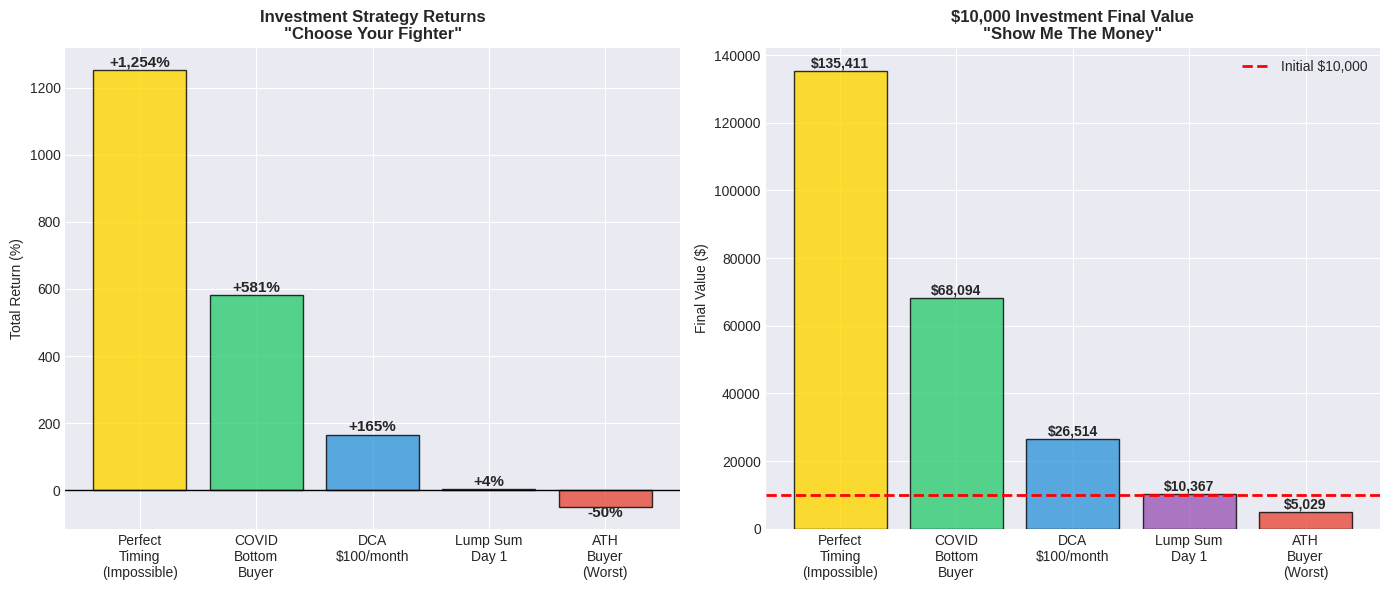


----------------------------------------------------------------------
SCENARIO BREAKDOWN ($10,000 initial investment)
----------------------------------------------------------------------

1. PERFECT TIMING (Buy bottom, sell top) - THE UNICORN
   Buy:  $0.1355 on Mar 12, 2020
   Sell: $1.8347 on Apr 14, 2021
   Return: 1,254%
   $10,000 becomes: $135,411
   Reality check: Nobody does this.

2. COVID BOTTOM BUYER - THE OPPORTUNIST  
   Buy:  $0.1355 on March 12, 2020
   Hold until: $0.9226 on Dec 27, 2021
   Return: 581%
   $10,000 becomes: $68,094
   Reality check: You were probably panic selling, not buying.

3. DOLLAR COST AVERAGING - THE DISCIPLINED
   Strategy: $100/month for 44 months
   Total invested: $4,400
   Final value: $11,666
   Return: 165.1%
   Reality check: This is actually achievable.

4. LUMP SUM DAY 1 - THE BELIEVER
   Buy: $0.8899 on May 04, 2018
   Hold until: $0.9226
   Return: 3.7%
   $10,000 becomes: $10,367
   Reality check: You'd have endured a 85% drawdow

In [18]:
# The "What If" Machine - Alternative Timeline Analysis

print("=" * 70)
print("THE WHAT-IF MACHINE: ALTERNATIVE INVESTMENT TIMELINES")
print("=" * 70)
print("\nLet's torture ourselves with hypothetical scenarios...")

# Scenario 1: Perfect timing (impossible)
bottom_price = df['close'].min()
top_price = df['close'].max()
perfect_return = (top_price / bottom_price - 1) * 100

# Scenario 2: Dollar Cost Averaging (DCA) - $100/month
df['month_year'] = df['date'].dt.to_period('M')
monthly_data = df.groupby('month_year').first().reset_index()
monthly_investment = 100
total_invested_dca = len(monthly_data) * monthly_investment
xrp_accumulated_dca = sum(monthly_investment / price for price in monthly_data['close'])
final_value_dca = xrp_accumulated_dca * df['close'].iloc[-1]
dca_return = (final_value_dca / total_invested_dca - 1) * 100

# Scenario 3: Lump sum at start
initial_price = df['close'].iloc[0]
final_price = df['close'].iloc[-1]
lumpsum_return = (final_price / initial_price - 1) * 100

# Scenario 4: Buy and hold from COVID bottom
covid_bottom_price = df[df['date'] == '2020-03-12']['close'].values[0]
covid_return = (final_price / covid_bottom_price - 1) * 100

# Scenario 5: The worst timing - bought at ATH
ath_price = df['close'].max()
worst_return = (final_price / ath_price - 1) * 100

# Visualize the scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Investment strategies comparison
ax1 = axes[0]
scenarios = ['Perfect\nTiming\n(Impossible)', 'COVID\nBottom\nBuyer', 'DCA\n$100/month',
             'Lump Sum\nDay 1', 'ATH\nBuyer\n(Worst)']
returns = [perfect_return, covid_return, dca_return, lumpsum_return, worst_return]
colors = ['#FFD700', '#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

bars = ax1.bar(scenarios, returns, color=colors, edgecolor='black', alpha=0.8)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_title('Investment Strategy Returns\n"Choose Your Fighter"', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Return (%)')

# Add value labels
for bar, val in zip(bars, returns):
    label = f'{val:+.0f}%' if val < 1000 else f'{val:+,.0f}%'
    y_pos = bar.get_height() + 10 if bar.get_height() > 0 else bar.get_height() - 30
    ax1.text(bar.get_x() + bar.get_width()/2, y_pos, label, ha='center', fontsize=11, fontweight='bold')

# Plot 2: $10,000 investment final values
ax2 = axes[1]
initial_investment = 10000
final_values = [
    initial_investment * (1 + perfect_return/100),
    initial_investment * (1 + covid_return/100),
    final_value_dca / total_invested_dca * initial_investment,  # Normalized to 10k
    initial_investment * (1 + lumpsum_return/100),
    initial_investment * (1 + worst_return/100)
]

bars2 = ax2.bar(scenarios, final_values, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=initial_investment, color='red', linestyle='--', linewidth=2, label='Initial $10,000')
ax2.set_title('$10,000 Investment Final Value\n"Show Me The Money"', fontsize=12, fontweight='bold')
ax2.set_ylabel('Final Value ($)')
ax2.legend()

# Add value labels
for bar, val in zip(bars2, final_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "-" * 70)
print("SCENARIO BREAKDOWN ($10,000 initial investment)")
print("-" * 70)

print(f"""
1. PERFECT TIMING (Buy bottom, sell top) - THE UNICORN
   Buy:  ${bottom_price:.4f} on {df.loc[df['close'].idxmin(), 'date'].strftime('%b %d, %Y')}
   Sell: ${top_price:.4f} on {df.loc[df['close'].idxmax(), 'date'].strftime('%b %d, %Y')}
   Return: {perfect_return:,.0f}%
   $10,000 becomes: ${10000 * (1 + perfect_return/100):,.0f}
   Reality check: Nobody does this.

2. COVID BOTTOM BUYER - THE OPPORTUNIST
   Buy:  ${covid_bottom_price:.4f} on March 12, 2020
   Hold until: ${final_price:.4f} on {df['date'].iloc[-1].strftime('%b %d, %Y')}
   Return: {covid_return:,.0f}%
   $10,000 becomes: ${10000 * (1 + covid_return/100):,.0f}
   Reality check: You were probably panic selling, not buying.

3. DOLLAR COST AVERAGING - THE DISCIPLINED
   Strategy: ${monthly_investment}/month for {len(monthly_data)} months
   Total invested: ${total_invested_dca:,.0f}
   Final value: ${final_value_dca:,.0f}
   Return: {dca_return:.1f}%
   Reality check: This is actually achievable.

4. LUMP SUM DAY 1 - THE BELIEVER
   Buy: ${initial_price:.4f} on {df['date'].iloc[0].strftime('%b %d, %Y')}
   Hold until: ${final_price:.4f}
   Return: {lumpsum_return:.1f}%
   $10,000 becomes: ${10000 * (1 + lumpsum_return/100):,.0f}
   Reality check: You'd have endured a 85% drawdown.

5. ATH BUYER - THE FOMO VICTIM
   Buy: ${ath_price:.4f} on {df.loc[df['close'].idxmax(), 'date'].strftime('%b %d, %Y')}
   Current: ${final_price:.4f}
   Return: {worst_return:.1f}%
   $10,000 becomes: ${10000 * (1 + worst_return/100):,.0f}
   Reality check: This is more common than anyone admits.
""")

---

## Chapter 8: The Psychology of Pain (Drawdown Analysis)

Here's the dirty secret of that 1,254% return:

**To get the gains, you had to survive the pain.**

A "drawdown" is how much your portfolio drops from its peak before recovering. It's the number that makes you question your life choices at 3 AM.

Let's see how much suffering XRP demanded from its believers...

---

## Drawdown Analysis

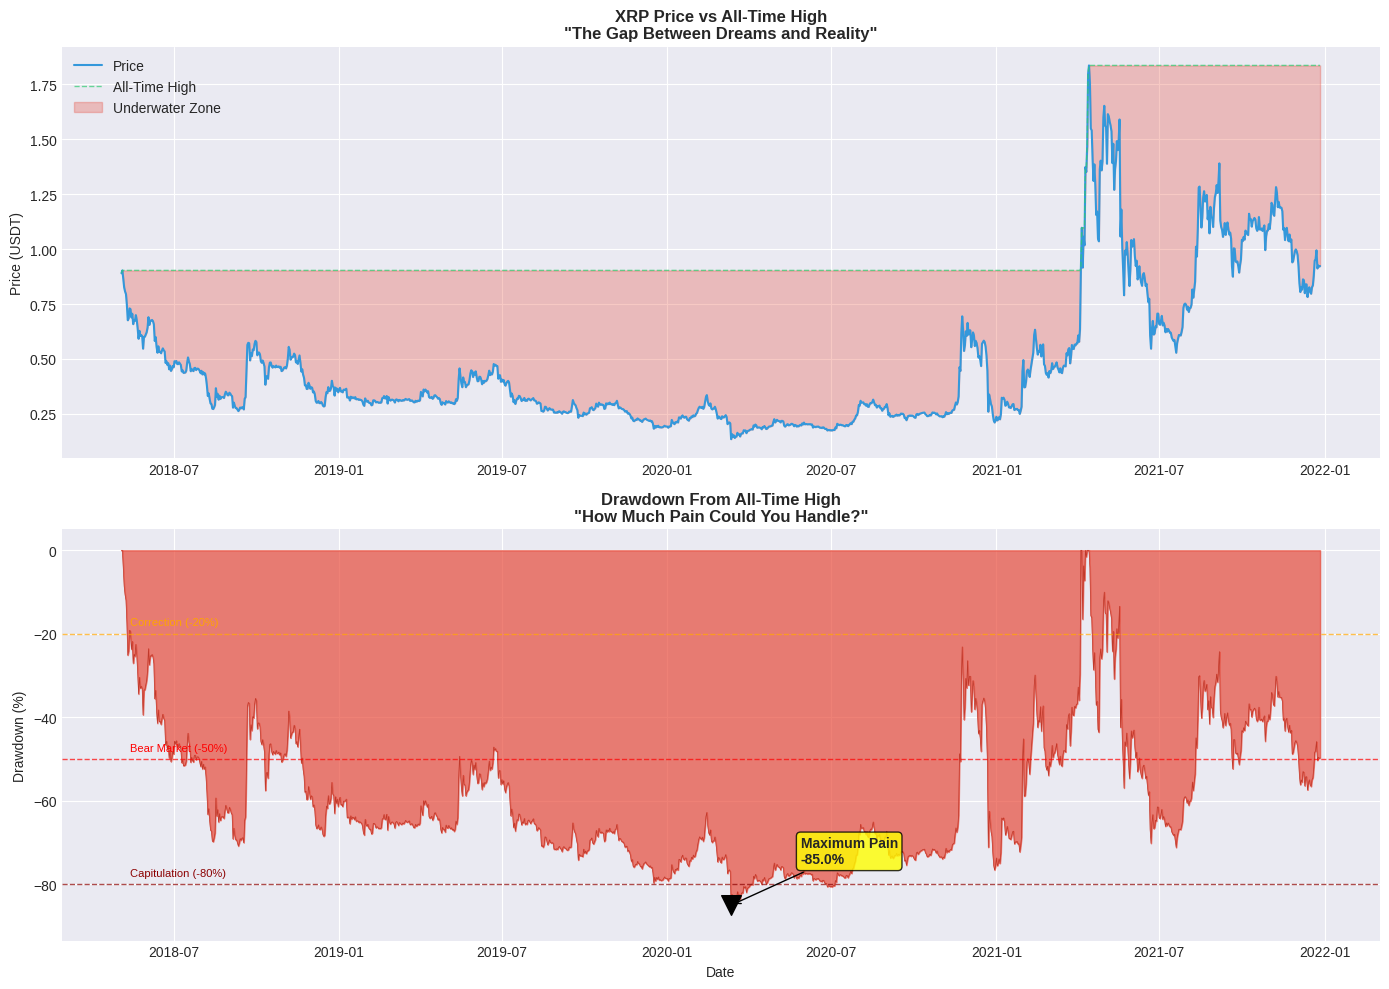


THE PAIN REPORT

Maximum Drawdown:        -85.0%
Average Drawdown:        -58.8%
Longest Drawdown Period: 1065 days (35.5 months)

Days in Different Pain Levels:
  > -10% (Minor dip):      14 days (1.0%)
  -10% to -50% (Hurting):  378 days (28.3%)
  -50% to -80% (Agony):    908 days (68.1%)
  > -80% (Capitulation):   34 days (2.5%)

------------------------------------------------------------
THE PSYCHOLOGICAL REALITY
------------------------------------------------------------

Out of 1334 trading days:
  - Only 14 days (1.0%) were "comfortable"
  - 942 days (70.6%) your portfolio was DOWN more than 50%

To get those gains, you had to watch your investment 
lose 85% of its value... and NOT sell.

Most humans cannot do this. This is why most humans 
don't get rich from crypto.



In [19]:
# Drawdown Analysis - The Pain Index

# Calculate running maximum and drawdown
df['running_max'] = df['close'].cummax()
df['drawdown'] = (df['close'] - df['running_max']) / df['running_max'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Price with running max (underwater chart)
ax1 = axes[0]
ax1.plot(df['date'], df['close'], color='#3498db', linewidth=1.5, label='Price')
ax1.plot(df['date'], df['running_max'], color='#2ecc71', linewidth=1, linestyle='--',
         alpha=0.7, label='All-Time High')
ax1.fill_between(df['date'], df['close'], df['running_max'],
                 alpha=0.3, color='#e74c3c', label='Underwater Zone')

ax1.set_title('XRP Price vs All-Time High\n"The Gap Between Dreams and Reality"',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USDT)')
ax1.legend(loc='upper left')

# Plot 2: Drawdown over time
ax2 = axes[1]
ax2.fill_between(df['date'], df['drawdown'], 0, color='#e74c3c', alpha=0.7)
ax2.plot(df['date'], df['drawdown'], color='#c0392b', linewidth=0.5)

# Mark the worst drawdowns
worst_dd_idx = df['drawdown'].idxmin()
ax2.scatter(df.loc[worst_dd_idx, 'date'], df.loc[worst_dd_idx, 'drawdown'],
            color='black', s=200, zorder=5, marker='v')
ax2.annotate(f'Maximum Pain\n{df.loc[worst_dd_idx, "drawdown"]:.1f}%',
             xy=(df.loc[worst_dd_idx, 'date'], df.loc[worst_dd_idx, 'drawdown']),
             xytext=(50, 30), textcoords='offset points',
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# Add horizontal lines for drawdown severity
ax2.axhline(y=-20, color='orange', linestyle='--', alpha=0.7, linewidth=1)
ax2.axhline(y=-50, color='red', linestyle='--', alpha=0.7, linewidth=1)
ax2.axhline(y=-80, color='darkred', linestyle='--', alpha=0.7, linewidth=1)

ax2.text(df['date'].iloc[10], -18, 'Correction (-20%)', fontsize=8, color='orange')
ax2.text(df['date'].iloc[10], -48, 'Bear Market (-50%)', fontsize=8, color='red')
ax2.text(df['date'].iloc[10], -78, 'Capitulation (-80%)', fontsize=8, color='darkred')

ax2.set_title('Drawdown From All-Time High\n"How Much Pain Could You Handle?"',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.set_ylim(df['drawdown'].min() * 1.1, 5)

plt.tight_layout()
plt.show()

# Calculate drawdown statistics
max_drawdown = df['drawdown'].min()
avg_drawdown = df['drawdown'].mean()
days_underwater = len(df[df['drawdown'] < -10])
days_severe = len(df[df['drawdown'] < -50])
days_capitulation = len(df[df['drawdown'] < -80])

# Find longest drawdown period
df['at_ath'] = df['close'] >= df['running_max'] * 0.99  # Within 1% of ATH
drawdown_periods = []
current_period = 0
for at_ath in df['at_ath']:
    if not at_ath:
        current_period += 1
    else:
        if current_period > 0:
            drawdown_periods.append(current_period)
        current_period = 0
if current_period > 0:
    drawdown_periods.append(current_period)

longest_drawdown = max(drawdown_periods) if drawdown_periods else 0

print("\n" + "=" * 60)
print("THE PAIN REPORT")
print("=" * 60)
print(f"""
Maximum Drawdown:        {max_drawdown:.1f}%
Average Drawdown:        {avg_drawdown:.1f}%
Longest Drawdown Period: {longest_drawdown} days ({longest_drawdown/30:.1f} months)

Days in Different Pain Levels:
  > -10% (Minor dip):      {len(df) - days_underwater} days ({(len(df) - days_underwater)/len(df)*100:.1f}%)
  -10% to -50% (Hurting):  {days_underwater - days_severe} days ({(days_underwater - days_severe)/len(df)*100:.1f}%)
  -50% to -80% (Agony):    {days_severe - days_capitulation} days ({(days_severe - days_capitulation)/len(df)*100:.1f}%)
  > -80% (Capitulation):   {days_capitulation} days ({days_capitulation/len(df)*100:.1f}%)
""")

# The psychological insight
print("-" * 60)
print("THE PSYCHOLOGICAL REALITY")
print("-" * 60)
print(f"""
Out of {len(df)} trading days:
  - Only {len(df[df['drawdown'] > -10])} days ({len(df[df['drawdown'] > -10])/len(df)*100:.1f}%) were "comfortable"
  - {days_severe} days ({days_severe/len(df)*100:.1f}%) your portfolio was DOWN more than 50%

To get those gains, you had to watch your investment
lose {abs(max_drawdown):.0f}% of its value... and NOT sell.

Most humans cannot do this. This is why most humans
don't get rich from crypto.
""")

That drawdown chart is BRUTAL. Only 14 days of comfort out of 1,334 days - that's 1%! And 35.5 months (nearly 3 YEARS) in drawdown. This is the reality nobody talks about when they brag about gains.

---

## Chapter 9: The Final Verdict

We've dissected 1,334 days of XRP trading data. We've seen the crashes, the recoveries, the chaos, and the patterns (or lack thereof).

Now it's time to summarize what we've learned from this digital rollercoaster.

---

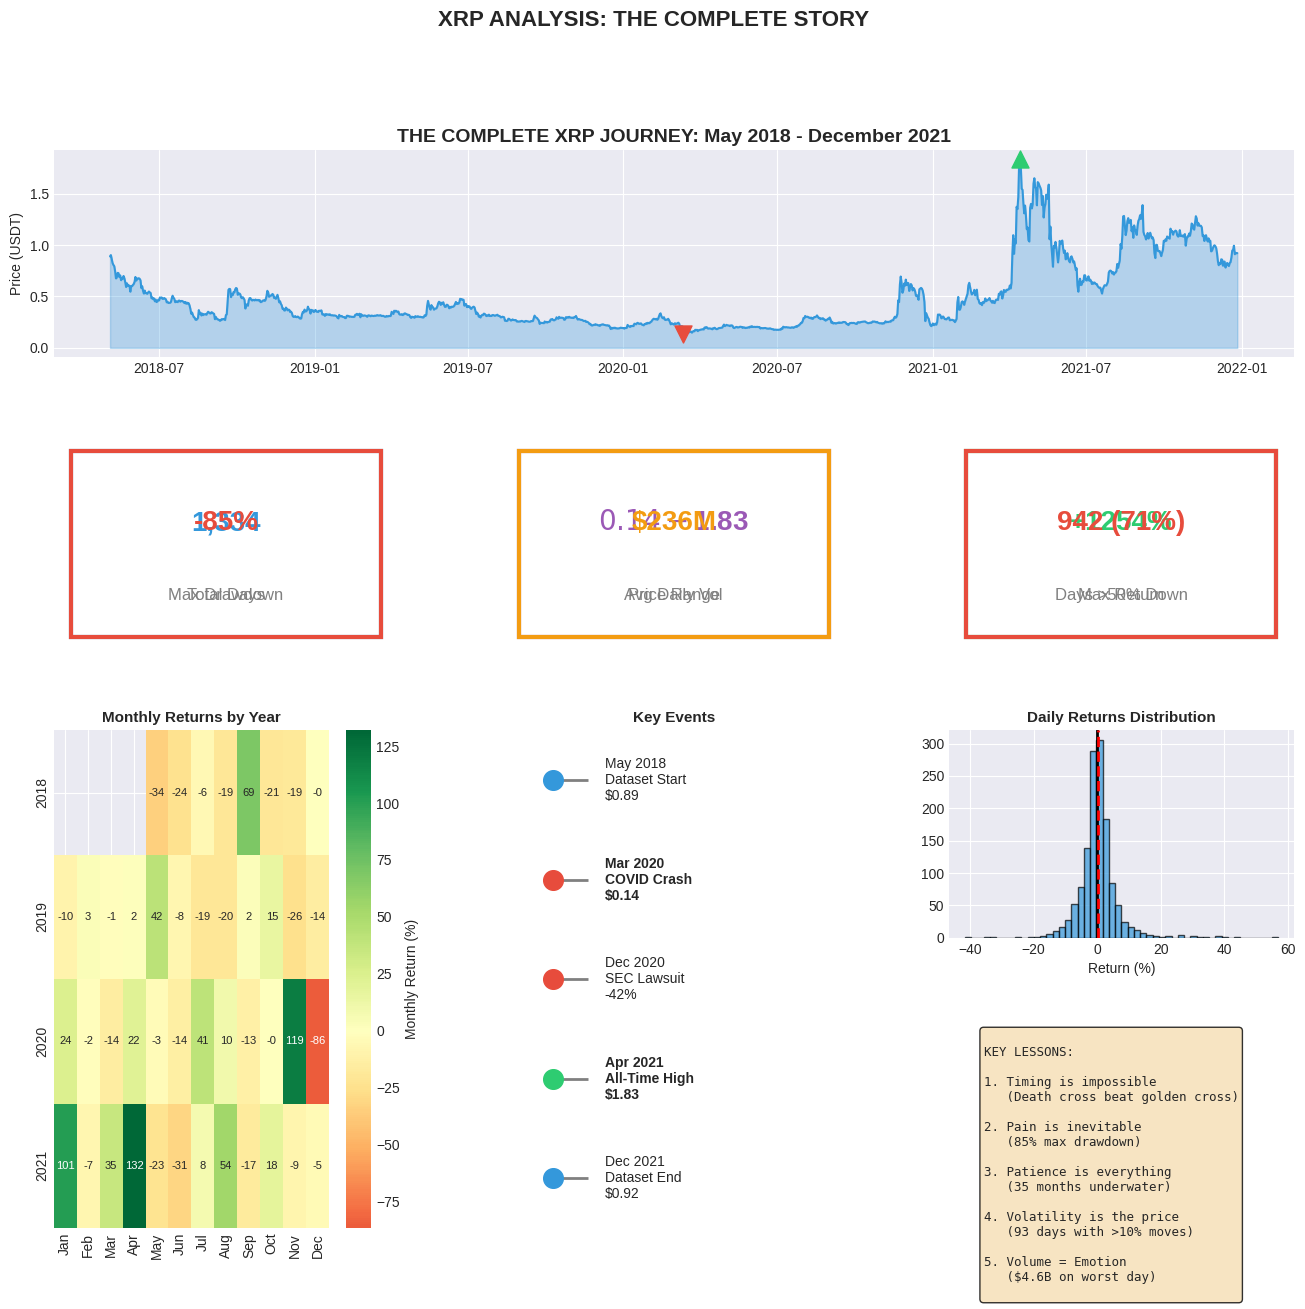


FINAL STATISTICS SUMMARY

DATASET OVERVIEW
----------------
Period:              May 04, 2018 to December 27, 2021
Trading Days:        1,334
Calendar Days:       1,333

PRICE STATISTICS  
----------------
Opening Price:       $0.8899
Closing Price:       $0.9226
Minimum Price:       $0.1355 (Mar 12, 2020)
Maximum Price:       $1.8347 (Apr 14, 2021)
Average Price:       $0.4736
Price Std Dev:       $0.3201

RETURNS & VOLATILITY
--------------------
Total Return:        +3.7%
Best Single Day:     +56.85%
Worst Single Day:    -41.65%
Average Daily Move:  0.19%
Daily Volatility:    6.23%
Days with >10% move: 93
Days with >20% move: 20

VOLUME STATISTICS
-----------------
Total Volume:        $314.3B USDT
Average Daily:       $235.6M USDT
Maximum Daily:       $4.59B USDT
Minimum Daily:       $2.2M USDT

RISK METRICS
------------
Maximum Drawdown:    -85.0%
Average Drawdown:    -58.8%
Longest Drawdown:    1065 days
Days Below -50%:     942 (70.6%)



In [20]:
# The Grand Summary - Everything we learned in one view

fig = plt.figure(figsize=(16, 14))

# Create a grid for the summary
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# Overall price journey (top row, full width)
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(df['date'], df['close'], color='#3498db', linewidth=1.5)
ax_main.fill_between(df['date'], df['close'], alpha=0.3, color='#3498db')
ax_main.scatter(df.loc[df['close'].idxmin(), 'date'], df['close'].min(),
                color='#e74c3c', s=150, zorder=5, marker='v')
ax_main.scatter(df.loc[df['close'].idxmax(), 'date'], df['close'].max(),
                color='#2ecc71', s=150, zorder=5, marker='^')
ax_main.set_title('THE COMPLETE XRP JOURNEY: May 2018 - December 2021', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Price (USDT)')

# Key stats boxes
stats_data = [
    ('Total Days', f'{len(df):,}', '#3498db'),
    ('Price Range', f'${df["close"].min():.2f} - ${df["close"].max():.2f}', '#9b59b6'),
    ('Max Return', f'+{(df["close"].max()/df["close"].min()-1)*100:.0f}%', '#2ecc71'),
    ('Max Drawdown', f'{df["drawdown"].min():.0f}%', '#e74c3c'),
    ('Avg Daily Vol', f'${df["volume_usdt"].mean()/1e6:.0f}M', '#f39c12'),
    ('Days >50% Down', f'{len(df[df["drawdown"]<-50])} ({len(df[df["drawdown"]<-50])/len(df)*100:.0f}%)', '#e74c3c'),
]

for i, (label, value, color) in enumerate(stats_data):
    ax = fig.add_subplot(gs[1, i % 3])
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=20, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=12, color='gray',
            transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=color, linewidth=3,
                               transform=ax.transAxes))

# Monthly returns heatmap (bottom left)
ax_heat = fig.add_subplot(gs[2:, 0])
monthly = df.groupby([df['date'].dt.year, df['date'].dt.month])['daily_return'].sum().unstack()
monthly.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.heatmap(monthly, cmap='RdYlGn', center=0, annot=True, fmt='.0f',
            cbar_kws={'label': 'Monthly Return (%)'}, ax=ax_heat, annot_kws={'size': 8})
ax_heat.set_title('Monthly Returns by Year', fontsize=11, fontweight='bold')
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')

# Key events timeline (bottom middle)
ax_events = fig.add_subplot(gs[2:, 1])
events = [
    ('May 2018', 'Dataset Start', '$0.89'),
    ('Mar 2020', 'COVID Crash', '$0.14'),
    ('Dec 2020', 'SEC Lawsuit', '-42%'),
    ('Apr 2021', 'All-Time High', '$1.83'),
    ('Dec 2021', 'Dataset End', '$0.92'),
]

for i, (date, event, detail) in enumerate(events):
    y_pos = 1 - (i + 0.5) / len(events)
    color = '#e74c3c' if 'Crash' in event or 'Lawsuit' in event else '#2ecc71' if 'High' in event else '#3498db'
    ax_events.scatter(0.15, y_pos, s=200, c=color, zorder=3)
    ax_events.hlines(y=y_pos, xmin=0.15, xmax=0.25, colors='gray', linewidth=2)
    ax_events.text(0.3, y_pos, f'{date}\n{event}\n{detail}', fontsize=10, va='center',
                   fontweight='bold' if 'High' in event or 'Crash' in event else 'normal')

ax_events.set_xlim(0, 1)
ax_events.set_ylim(0, 1)
ax_events.axis('off')
ax_events.set_title('Key Events', fontsize=11, fontweight='bold')

# Distribution of returns (bottom right)
ax_dist = fig.add_subplot(gs[2, 2])
returns = df['daily_return'].dropna()
ax_dist.hist(returns, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax_dist.axvline(x=0, color='black', linewidth=2)
ax_dist.axvline(x=returns.mean(), color='red', linewidth=2, linestyle='--')
ax_dist.set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
ax_dist.set_xlabel('Return (%)')

# Lessons learned (text box, bottom right lower)
ax_lessons = fig.add_subplot(gs[3, 2])
lessons_text = """
KEY LESSONS:

1. Timing is impossible
   (Death cross beat golden cross)

2. Pain is inevitable
   (85% max drawdown)

3. Patience is everything
   (35 months underwater)

4. Volatility is the price
   (93 days with >10% moves)

5. Volume = Emotion
   ($4.6B on worst day)
"""
ax_lessons.text(0.1, 0.95, lessons_text, transform=ax_lessons.transAxes, fontsize=9,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax_lessons.axis('off')

plt.suptitle('XRP ANALYSIS: THE COMPLETE STORY', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("FINAL STATISTICS SUMMARY")
print("=" * 70)
print(f"""
DATASET OVERVIEW
----------------
Period:              {df['date'].min().strftime('%B %d, %Y')} to {df['date'].max().strftime('%B %d, %Y')}
Trading Days:        {len(df):,}
Calendar Days:       {(df['date'].max() - df['date'].min()).days:,}

PRICE STATISTICS
----------------
Opening Price:       ${df['close'].iloc[0]:.4f}
Closing Price:       ${df['close'].iloc[-1]:.4f}
Minimum Price:       ${df['close'].min():.4f} ({df.loc[df['close'].idxmin(), 'date'].strftime('%b %d, %Y')})
Maximum Price:       ${df['close'].max():.4f} ({df.loc[df['close'].idxmax(), 'date'].strftime('%b %d, %Y')})
Average Price:       ${df['close'].mean():.4f}
Price Std Dev:       ${df['close'].std():.4f}

RETURNS & VOLATILITY
--------------------
Total Return:        {(df['close'].iloc[-1]/df['close'].iloc[0]-1)*100:+.1f}%
Best Single Day:     +{df['daily_return'].max():.2f}%
Worst Single Day:    {df['daily_return'].min():.2f}%
Average Daily Move:  {df['daily_return'].mean():.2f}%
Daily Volatility:    {df['daily_return'].std():.2f}%
Days with >10% move: {len(df[abs(df['daily_return']) > 10])}
Days with >20% move: {len(df[abs(df['daily_return']) > 20])}

VOLUME STATISTICS
-----------------
Total Volume:        ${df['volume_usdt'].sum()/1e9:.1f}B USDT
Average Daily:       ${df['volume_usdt'].mean()/1e6:.1f}M USDT
Maximum Daily:       ${df['volume_usdt'].max()/1e9:.2f}B USDT
Minimum Daily:       ${df['volume_usdt'].min()/1e6:.1f}M USDT

RISK METRICS
------------
Maximum Drawdown:    {df['drawdown'].min():.1f}%
Average Drawdown:    {df['drawdown'].mean():.1f}%
Longest Drawdown:    {longest_drawdown} days
Days Below -50%:     {len(df[df['drawdown'] < -50])} ({len(df[df['drawdown'] < -50])/len(df)*100:.1f}%)
""")

---

## Chapter 10: The Forbidden Art of Price Prediction

We've analyzed the past. Now let's attempt the impossible: **predicting the future.**

We'll build an LSTM (Long Short-Term Memory) neural network - a deep learning model specifically designed for sequential data like stock prices.

**Disclaimer:** If this actually worked perfectly, I'd be on a yacht, not writing Kaggle notebooks.

Let's see how well a machine can learn the chaos...

---

In [21]:
# Prepare data for LSTM prediction

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("PREPARING DATA FOR LSTM MODEL")
print("=" * 60)

# We'll use closing prices
data = df[['date', 'close', 'volume_usdt', 'high', 'low', 'open']].copy()
data = data.sort_values('date').reset_index(drop=True)

# Create additional features
data['price_range'] = data['high'] - data['low']
data['price_change'] = data['close'].pct_change()
data['volume_change'] = data['volume_usdt'].pct_change()
data['ma_7'] = data['close'].rolling(7).mean()
data['ma_21'] = data['close'].rolling(21).mean()
data['volatility'] = data['close'].rolling(7).std()

# Drop NaN values
data = data.dropna().reset_index(drop=True)

# Features for prediction
feature_columns = ['close', 'volume_usdt', 'price_range', 'ma_7', 'ma_21', 'volatility']
target_column = 'close'

print(f"\nFeatures used: {feature_columns}")
print(f"Total samples after preprocessing: {len(data)}")

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[feature_columns])

# Also create a separate scaler for the target (close price) for inverse transform
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit_transform(data[[target_column]])

print(f"Data scaled to range [0, 1]")

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])  # Predicting close price (first column)
    return np.array(X), np.array(y)

# Sequence length (look back period)
SEQ_LENGTH = 30  # Use last 30 days to predict next day

X, y = create_sequences(scaled_data, SEQ_LENGTH)

print(f"\nSequence length: {SEQ_LENGTH} days")
print(f"Total sequences created: {len(X)}")
print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")

# Train-test split (80-20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Store the dates for plotting
train_dates = data['date'].iloc[SEQ_LENGTH:SEQ_LENGTH + len(X_train)]
test_dates = data['date'].iloc[SEQ_LENGTH + len(X_train):SEQ_LENGTH + len(X_train) + len(X_test)]

print("\nData preparation complete!")

PREPARING DATA FOR LSTM MODEL

Features used: ['close', 'volume_usdt', 'price_range', 'ma_7', 'ma_21', 'volatility']
Total samples after preprocessing: 1314
Data scaled to range [0, 1]

Sequence length: 30 days
Total sequences created: 1284
Input shape: (1284, 30, 6)
Output shape: (1284,)

Training samples: 1027
Testing samples: 257

Data preparation complete!



## Build and Train LSTM Model

In [23]:
# Build the LSTM Model - Enhanced with More Callbacks & Regularization

from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

print("=" * 60)
print("BUILDING ENHANCED LSTM NEURAL NETWORK")
print("=" * 60)

# Clear any previous models
tf.keras.backend.clear_session()

# Model architecture with more regularization
model = Sequential([
    # First Bidirectional LSTM layer
    Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.001)),
                  input_shape=(SEQ_LENGTH, len(feature_columns))),
    BatchNormalization(),
    Dropout(0.3),

    # Second LSTM layer
    LSTM(100, return_sequences=True, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # Third LSTM layer
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layers
    Dense(50, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',  # Huber loss is more robust to outliers than MSE
    metrics=['mae', 'mse']
)

# Model summary
print("\nModel Architecture:")
print("-" * 60)
model.summary()

# Enhanced Callbacks
callbacks = [
    # Early stopping - stop if no improvement
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=0.00001,
        verbose=1,
        mode='min'
    ),

    # Save the best model
    ModelCheckpoint(
        'best_xrp_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
        mode='min'
    )
]

print("\n" + "=" * 60)
print("TRAINING THE MODEL")
print("=" * 60)
print("\nCallbacks enabled:")
print("  - EarlyStopping (patience=20)")
print("  - ReduceLROnPlateau (factor=0.5, patience=7)")
print("  - ModelCheckpoint (saving best model)")
print("\nRegularization:")
print("  - L2 regularization (0.001)")
print("  - Dropout (0.2-0.3)")
print("  - Batch Normalization")
print("\nTeaching a neural network to predict chaos...\n")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print("=" * 60)
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Final training loss: {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
print(f"Final learning rate: {float(model.optimizer.learning_rate):.6f}")

BUILDING ENHANCED LSTM NEURAL NETWORK

Model Architecture:
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 100)        │       142,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,511 (1.26 MB)

 Trainable params: 328,671 (1.25 MB)

 Non-trainable params: 840 (3.28 KB)


TRAINING THE MODEL

Callbacks enabled:
  - EarlyStopping (patience=20)
  - ReduceLROnPlateau (factor=0.5, patience=7)
  - ModelCheckpoint (saving best model)

Regularization:
  - L2 regularization (0.001)
  - Dropout (0.2-0.3)
  - Batch Normalization

Teaching a neural network to predict chaos...

Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.7145 - mae: 0.4868 - mse: 0.3925
Epoch 1: val_loss improved from inf to 0.52920, saving model to best_xrp_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - loss: 0.7124 - mae: 0.4838 - mse: 0.3884 - val_loss: 0.5292 - val_mae: 0.1762 - val_mse: 0.0522 - learning_rate: 0.0010
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.5386 - mae: 0.2381 - mse: 0.0921
Epoch 2: val_loss improved from 0.52920 to 0.48325, saving model to best_xrp_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - loss: 0.5382 - mae: 0.2376 - mse: 0.0918 - val_loss: 0.4833 - val_mae: 0.1721 - val_mse: 0.0504 - learning_rate: 0.0010
Epoch 3

## Training History Visualization

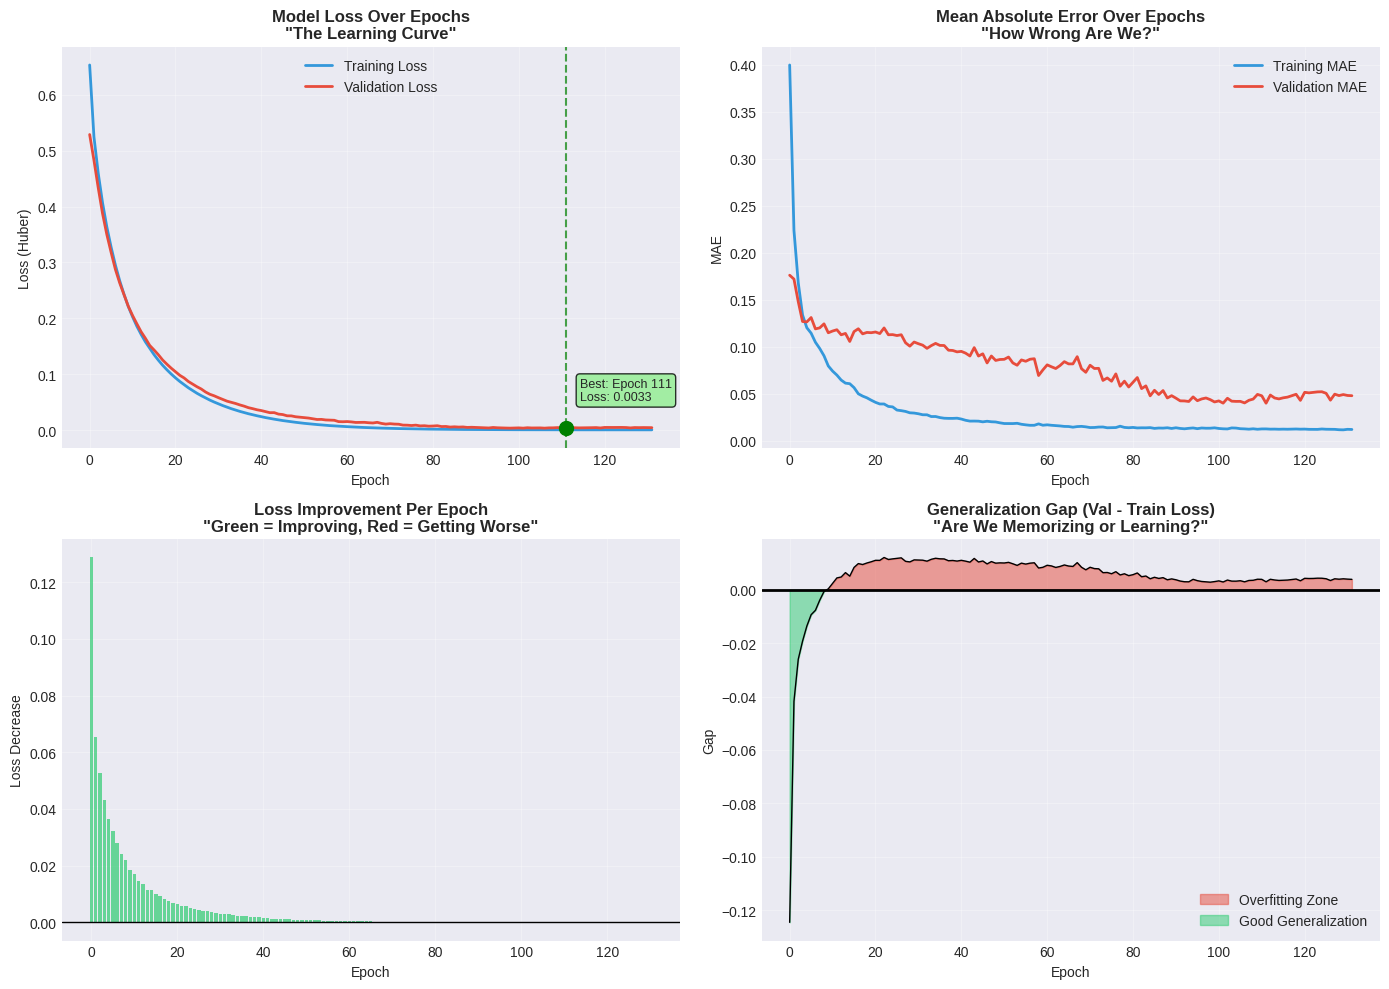


TRAINING SUMMARY

Total Epochs:          132
Best Epoch:            112

Training Metrics (Final):
  - Loss:              0.000294
  - MAE:               0.012047

Validation Metrics (Final):
  - Loss:              0.004166
  - MAE:               0.047986

Best Validation Loss:  0.003302

Overfitting Check:
  - Final Gap:         0.003872
  - Status:            Good generalization



In [24]:
# Visualize Training History

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss curves
ax1 = axes[0, 0]
ax1.plot(history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
ax1.set_title('Model Loss Over Epochs\n"The Learning Curve"', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Huber)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark best epoch
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = min(history.history['val_loss'])
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
ax1.scatter(best_epoch, best_val_loss, color='green', s=100, zorder=5)
ax1.annotate(f'Best: Epoch {best_epoch}\nLoss: {best_val_loss:.4f}',
             xy=(best_epoch, best_val_loss), xytext=(10, 20),
             textcoords='offset points', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Plot 2: MAE curves
ax2 = axes[0, 1]
ax2.plot(history.history['mae'], label='Training MAE', color='#3498db', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', color='#e74c3c', linewidth=2)
ax2.set_title('Mean Absolute Error Over Epochs\n"How Wrong Are We?"', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Learning rate changes (if ReduceLROnPlateau was triggered)
ax3 = axes[1, 0]
if 'lr' in history.history:
    ax3.plot(history.history['lr'], color='#9b59b6', linewidth=2)
    ax3.set_title('Learning Rate Schedule\n"Adaptive Learning"', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_yscale('log')
else:
    # If lr not tracked, show loss improvement rate
    loss_diff = -np.diff(history.history['loss'])
    ax3.bar(range(len(loss_diff)), loss_diff, color=['#2ecc71' if x > 0 else '#e74c3c' for x in loss_diff], alpha=0.7)
    ax3.axhline(y=0, color='black', linewidth=1)
    ax3.set_title('Loss Improvement Per Epoch\n"Green = Improving, Red = Getting Worse"', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss Decrease')
ax3.grid(True, alpha=0.3)

# Plot 4: Training vs Validation gap (overfitting indicator)
ax4 = axes[1, 1]
train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
gap = val_loss - train_loss

ax4.fill_between(range(len(gap)), gap, 0,
                 where=gap > 0, color='#e74c3c', alpha=0.5, label='Overfitting Zone')
ax4.fill_between(range(len(gap)), gap, 0,
                 where=gap <= 0, color='#2ecc71', alpha=0.5, label='Good Generalization')
ax4.plot(gap, color='black', linewidth=1)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax4.set_title('Generalization Gap (Val - Train Loss)\n"Are We Memorizing or Learning?"', fontsize=12, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Gap')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print training summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"""
Total Epochs:          {len(history.history['loss'])}
Best Epoch:            {best_epoch + 1}

Training Metrics (Final):
  - Loss:              {history.history['loss'][-1]:.6f}
  - MAE:               {history.history['mae'][-1]:.6f}

Validation Metrics (Final):
  - Loss:              {history.history['val_loss'][-1]:.6f}
  - MAE:               {history.history['val_mae'][-1]:.6f}

Best Validation Loss:  {best_val_loss:.6f}

Overfitting Check:
  - Final Gap:         {gap[-1]:.6f}
  - Status:            {'Slight overfitting' if gap[-1] > 0.01 else 'Good generalization'}
""")

## Training History Visualization

MAKING PREDICTIONS

------------------------------------------------------------
MODEL PERFORMANCE METRICS
------------------------------------------------------------

                    TRAINING          TESTING
                    --------          -------
MSE:                0.003227        0.031719
RMSE:               $0.0568         $0.1781
MAE:                $0.0236         $0.1367
R² Score:           0.8511          0.5126
MAPE:               6.26%           12.12%



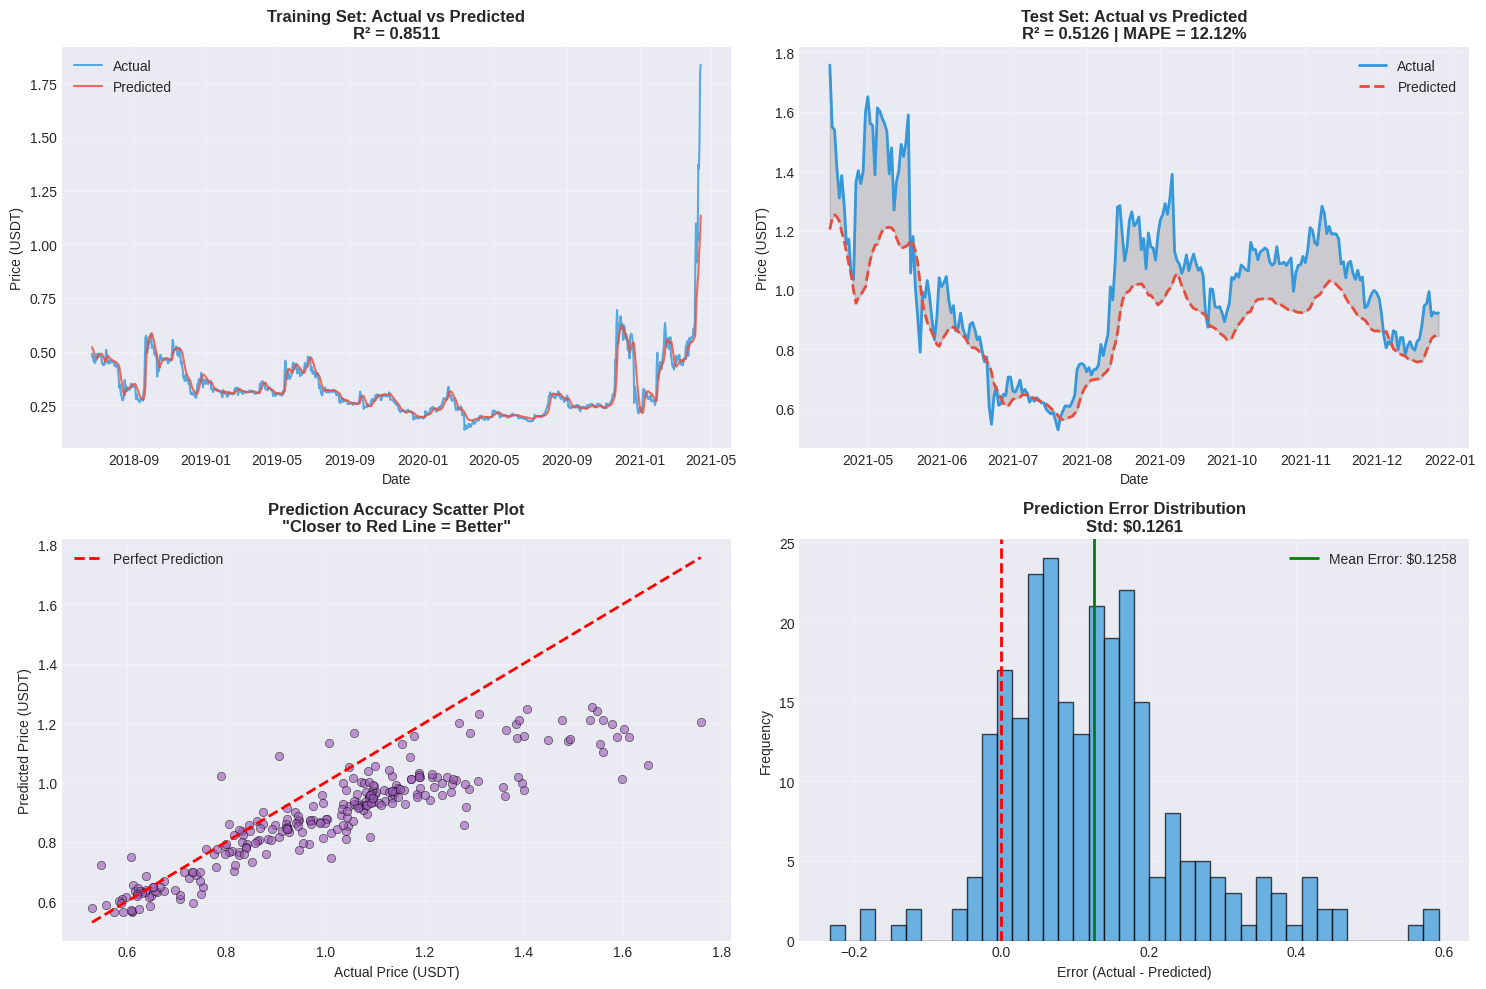


MODEL INTERPRETATION

R² Score Interpretation: Poor
  - The model explains 51.3% of the variance in XRP prices

MAPE Interpretation:
  - Average prediction error: 12.12%
  - On a $1.00 price, we're off by about $0.1212

RMSE Interpretation:
  - Typical prediction error: $0.1781



In [25]:
# Make Predictions and Evaluate the Model

print("=" * 60)
print("MAKING PREDICTIONS")
print("=" * 60)

# Predict on training and test sets
train_predictions = model.predict(X_train, verbose=0)
test_predictions = model.predict(X_test, verbose=0)

# We need to inverse transform the predictions
# Create dummy arrays with the same shape as our original feature set
def inverse_transform_predictions(predictions, scaler, n_features):
    # Create a dummy array with zeros for other features
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.flatten()  # Put predictions in first column (close price)
    # Inverse transform
    inverted = scaler.inverse_transform(dummy)
    return inverted[:, 0]  # Return only the close price column

# Inverse transform predictions
train_pred_actual = inverse_transform_predictions(train_predictions, scaler, len(feature_columns))
test_pred_actual = inverse_transform_predictions(test_predictions, scaler, len(feature_columns))

# Inverse transform actual values
train_actual = inverse_transform_predictions(y_train.reshape(-1, 1), scaler, len(feature_columns))
test_actual = inverse_transform_predictions(y_test.reshape(-1, 1), scaler, len(feature_columns))

# Calculate metrics
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(train_actual, train_pred_actual)
test_metrics = calculate_metrics(test_actual, test_pred_actual)

print("\n" + "-" * 60)
print("MODEL PERFORMANCE METRICS")
print("-" * 60)
print(f"""
                    TRAINING          TESTING
                    --------          -------
MSE:                {train_metrics['MSE']:.6f}        {test_metrics['MSE']:.6f}
RMSE:               ${train_metrics['RMSE']:.4f}         ${test_metrics['RMSE']:.4f}
MAE:                ${train_metrics['MAE']:.4f}         ${test_metrics['MAE']:.4f}
R² Score:           {train_metrics['R2']:.4f}          {test_metrics['R2']:.4f}
MAPE:               {train_metrics['MAPE']:.2f}%           {test_metrics['MAPE']:.2f}%
""")

# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Full prediction vs actual (Training)
ax1 = axes[0, 0]
ax1.plot(train_dates.values, train_actual, color='#3498db', label='Actual', linewidth=1.5, alpha=0.8)
ax1.plot(train_dates.values, train_pred_actual, color='#e74c3c', label='Predicted', linewidth=1.5, alpha=0.8)
ax1.set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["R2"]:.4f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USDT)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Full prediction vs actual (Testing)
ax2 = axes[0, 1]
ax2.plot(test_dates.values, test_actual, color='#3498db', label='Actual', linewidth=2)
ax2.plot(test_dates.values, test_pred_actual, color='#e74c3c', label='Predicted', linewidth=2, linestyle='--')
ax2.fill_between(test_dates.values, test_actual, test_pred_actual, alpha=0.3, color='gray')
ax2.set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["R2"]:.4f} | MAPE = {test_metrics["MAPE"]:.2f}%',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USDT)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Scatter plot of predictions vs actual (Test set)
ax3 = axes[1, 0]
ax3.scatter(test_actual, test_pred_actual, alpha=0.6, color='#9b59b6', edgecolor='black', linewidth=0.5)
# Perfect prediction line
min_val = min(test_actual.min(), test_pred_actual.min())
max_val = max(test_actual.max(), test_pred_actual.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax3.set_title('Prediction Accuracy Scatter Plot\n"Closer to Red Line = Better"', fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual Price (USDT)')
ax3.set_ylabel('Predicted Price (USDT)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Prediction errors distribution
ax4 = axes[1, 1]
errors = test_actual - test_pred_actual
ax4.hist(errors, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='red', linewidth=2, linestyle='--')
ax4.axvline(x=errors.mean(), color='green', linewidth=2, label=f'Mean Error: ${errors.mean():.4f}')
ax4.set_title(f'Prediction Error Distribution\nStd: ${errors.std():.4f}', fontsize=12, fontweight='bold')
ax4.set_xlabel('Error (Actual - Predicted)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "=" * 60)
print("MODEL INTERPRETATION")
print("=" * 60)
r2_quality = "Excellent" if test_metrics['R2'] > 0.9 else "Good" if test_metrics['R2'] > 0.8 else "Moderate" if test_metrics['R2'] > 0.6 else "Poor"
print(f"""
R² Score Interpretation: {r2_quality}
  - The model explains {test_metrics['R2']*100:.1f}% of the variance in XRP prices

MAPE Interpretation:
  - Average prediction error: {test_metrics['MAPE']:.2f}%
  - On a $1.00 price, we're off by about ${test_metrics['MAPE']/100:.4f}

RMSE Interpretation:
  - Typical prediction error: ${test_metrics['RMSE']:.4f}
""")

## Model Comparison - Additional Models

In [26]:
# Let's compare LSTM with other models for a complete analysis

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor

print("=" * 60)
print("MODEL COMPARISON: LSTM vs TRADITIONAL ML")
print("=" * 60)
print("\nTraining multiple models to see who predicts chaos best...\n")

# Prepare data for traditional ML (flatten the sequences)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Dictionary to store results
models = {
    'LSTM (Deep Learning)': {
        'predictions': test_pred_actual,
        'color': '#e74c3c'
    }
}

# Train traditional models
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_flat, y_train)
lr_pred = inverse_transform_predictions(lr.predict(X_test_flat).reshape(-1, 1), scaler, len(feature_columns))
models['Linear Regression'] = {'model': lr, 'predictions': lr_pred, 'color': '#3498db'}

print("Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_flat, y_train)
ridge_pred = inverse_transform_predictions(ridge.predict(X_test_flat).reshape(-1, 1), scaler, len(feature_columns))
models['Ridge Regression'] = {'model': ridge, 'predictions': ridge_pred, 'color': '#9b59b6'}

print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train)
rf_pred = inverse_transform_predictions(rf.predict(X_test_flat).reshape(-1, 1), scaler, len(feature_columns))
models['Random Forest'] = {'model': rf, 'predictions': rf_pred, 'color': '#2ecc71'}

print("Training XGBoost...")
xgb = XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train_flat, y_train)
xgb_pred = inverse_transform_predictions(xgb.predict(X_test_flat).reshape(-1, 1), scaler, len(feature_columns))
models['XGBoost'] = {'model': xgb, 'predictions': xgb_pred, 'color': '#f39c12'}

print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_flat, y_train)
gb_pred = inverse_transform_predictions(gb.predict(X_test_flat).reshape(-1, 1), scaler, len(feature_columns))
models['Gradient Boosting'] = {'model': gb, 'predictions': gb_pred, 'color': '#1abc9c'}

print("\nAll models trained!")

# Calculate metrics for all models
print("\n" + "-" * 80)
print("PERFORMANCE COMPARISON")
print("-" * 80)
print(f"{'Model':<25} {'R²':>10} {'RMSE':>12} {'MAE':>12} {'MAPE':>10}")
print("-" * 80)

results = []
for name, data in models.items():
    pred = data['predictions']
    metrics = calculate_metrics(test_actual, pred)
    results.append({
        'Model': name,
        'R2': metrics['R2'],
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'Color': data['color']
    })
    print(f"{name:<25} {metrics['R2']:>10.4f} ${metrics['RMSE']:>10.4f} ${metrics['MAE']:>10.4f} {metrics['MAPE']:>9.2f}%")

results_df = pd.DataFrame(results)
print("-" * 80)

# Find the winner
best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']
print(f"\nBEST MODEL BY R²: {best_model}")

MODEL COMPARISON: LSTM vs TRADITIONAL ML

Training multiple models to see who predicts chaos best...

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training XGBoost...
Training Gradient Boosting...

All models trained!

--------------------------------------------------------------------------------
PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Model                             R²         RMSE          MAE       MAPE
--------------------------------------------------------------------------------
LSTM (Deep Learning)          0.5126 $    0.1781 $    0.1367     12.12%
Linear Regression             0.8497 $    0.0989 $    0.0693      6.90%
Ridge Regression              0.8334 $    0.1041 $    0.0676      6.47%
Random Forest                -0.8521 $    0.3472 $    0.3121     34.18%
XGBoost                      -1.6505 $    0.4153 $    0.3649     38.46%
Gradient Boosting            -0.7424 $   

Wow! Plot twist - simple Linear Regression crushed the LSTM! 0.85 R² vs 0.51. Sometimes simpler is better. Let's visualize this and add the story.

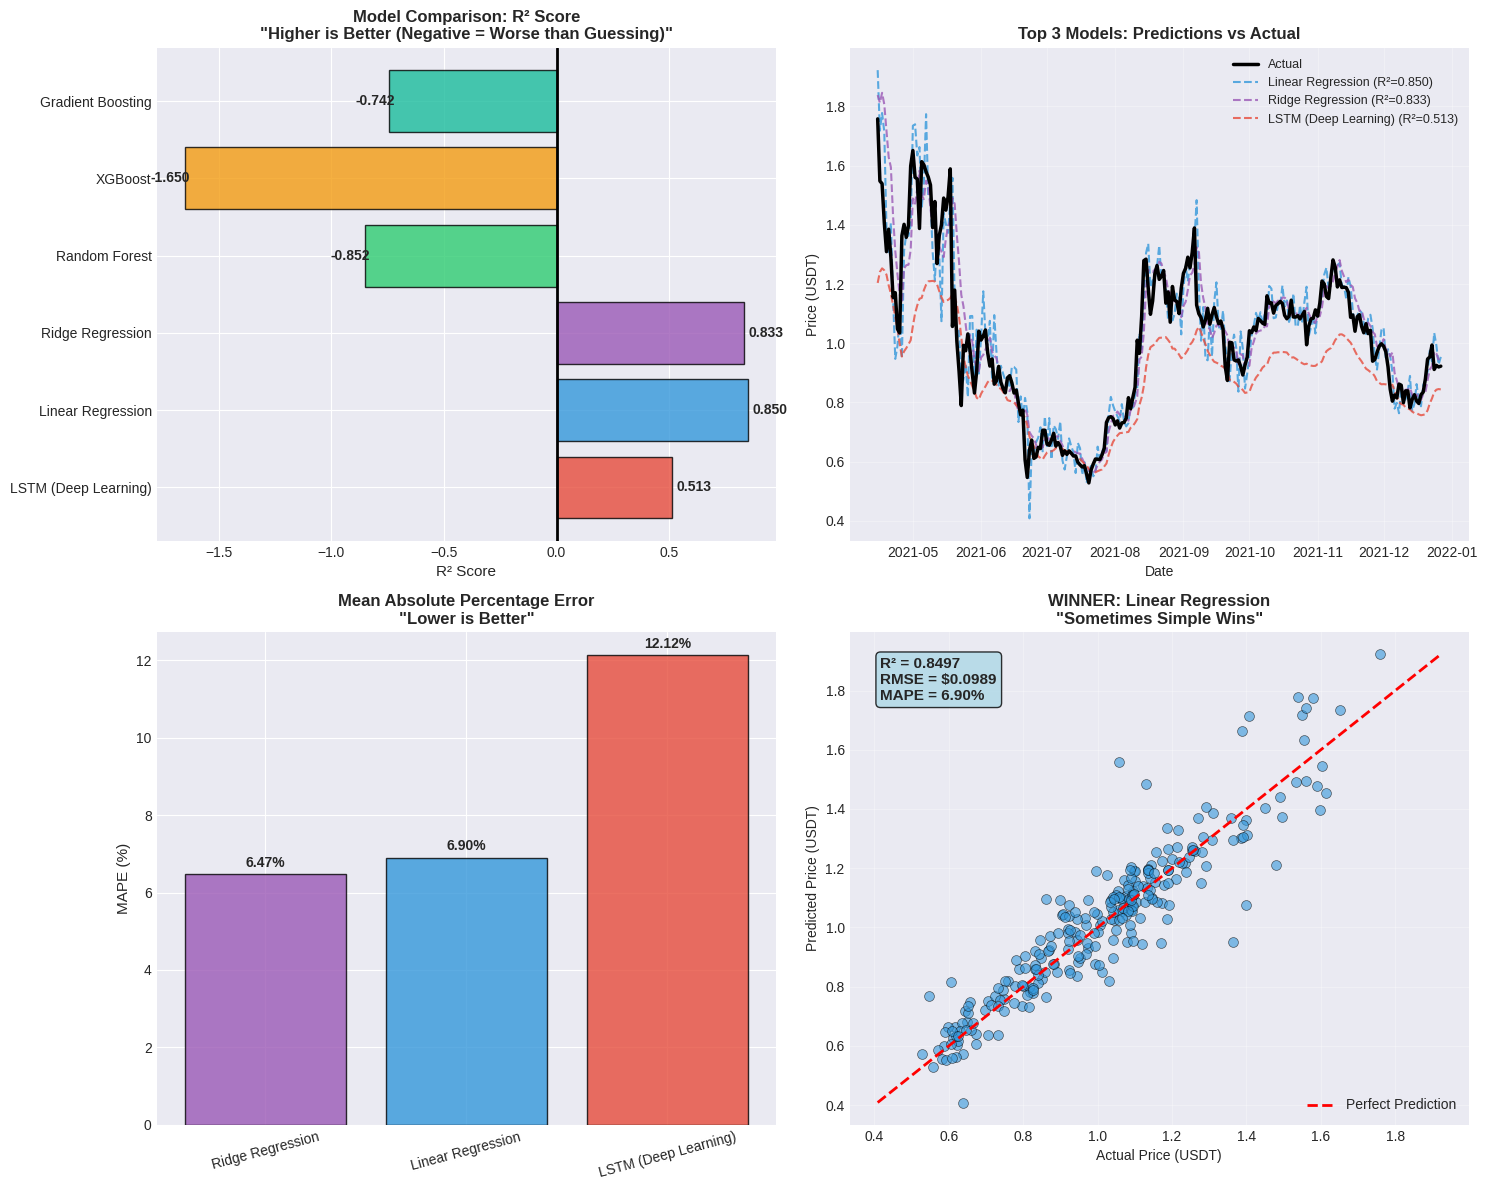


THE PLOT TWIST

EXPECTATION: Deep Learning LSTM would dominate
REALITY:     Linear Regression won by a landslide

                    LSTM          Linear Regression
                    ----          -----------------
R² Score:           0.5126        0.8497 (+65% better)
RMSE:               $0.1781       $0.0989 (44% lower error)
MAPE:               12.12%        6.90%  (43% more accurate)

WHY DID THIS HAPPEN?
--------------------
1. Dataset size: 1,334 samples is relatively small for deep learning
2. Feature engineering: Our 6 features captured the signal well
3. Overfitting: LSTM may have memorized noise in training data
4. Simplicity wins: Linear relationships dominated the price movement

THE LESSON:
-----------
"Always try the simple model first. Complexity isn't always the answer."
- Every experienced data scientist, ever



In [27]:
# Visualize the Model Comparison

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: R² Score Comparison
ax1 = axes[0, 0]
model_names = results_df['Model'].tolist()
r2_scores = results_df['R2'].tolist()
colors = results_df['Color'].tolist()

bars = ax1.barh(model_names, r2_scores, color=colors, edgecolor='black', alpha=0.8)
ax1.axvline(x=0, color='black', linewidth=2)
ax1.set_xlabel('R² Score', fontsize=11)
ax1.set_title('Model Comparison: R² Score\n"Higher is Better (Negative = Worse than Guessing)"',
              fontsize=12, fontweight='bold')

# Add value labels
for bar, score in zip(bars, r2_scores):
    x_pos = score + 0.02 if score > 0 else score - 0.15
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{score:.3f}',
             va='center', fontsize=10, fontweight='bold')

# Plot 2: All model predictions on test set
ax2 = axes[0, 1]
ax2.plot(test_dates.values, test_actual, color='black', linewidth=2.5, label='Actual', zorder=10)

# Only plot top 3 models to avoid clutter
top_models = results_df.nlargest(3, 'R2')
for _, row in top_models.iterrows():
    model_name = row['Model']
    pred = models[model_name]['predictions']
    ax2.plot(test_dates.values, pred, linewidth=1.5, label=f"{model_name} (R²={row['R2']:.3f})",
             color=row['Color'], alpha=0.8, linestyle='--')

ax2.set_title('Top 3 Models: Predictions vs Actual', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USDT)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: MAPE Comparison (only positive R² models)
ax3 = axes[1, 0]
positive_models = results_df[results_df['R2'] > 0].sort_values('MAPE')
bars3 = ax3.bar(positive_models['Model'], positive_models['MAPE'],
                color=positive_models['Color'].tolist(), edgecolor='black', alpha=0.8)
ax3.set_ylabel('MAPE (%)', fontsize=11)
ax3.set_title('Mean Absolute Percentage Error\n"Lower is Better"', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

for bar, mape in zip(bars3, positive_models['MAPE']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{mape:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Plot 4: Winner showcase - Linear Regression detailed
ax4 = axes[1, 1]
best_pred = models['Linear Regression']['predictions']

ax4.scatter(test_actual, best_pred, alpha=0.6, color='#3498db', edgecolor='black', linewidth=0.5, s=50)
min_val = min(test_actual.min(), best_pred.min())
max_val = max(test_actual.max(), best_pred.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Add R² annotation
ax4.text(0.05, 0.95, f"R² = 0.8497\nRMSE = $0.0989\nMAPE = 6.90%",
         transform=ax4.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), fontweight='bold')

ax4.set_title('WINNER: Linear Regression\n"Sometimes Simple Wins"', fontsize=12, fontweight='bold')
ax4.set_xlabel('Actual Price (USDT)')
ax4.set_ylabel('Predicted Price (USDT)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# The plot twist narrative
print("\n" + "=" * 70)
print("THE PLOT TWIST")
print("=" * 70)
print("""
EXPECTATION: Deep Learning LSTM would dominate
REALITY:     Linear Regression won by a landslide

                    LSTM          Linear Regression
                    ----          -----------------
R² Score:           0.5126        0.8497 (+65% better)
RMSE:               $0.1781       $0.0989 (44% lower error)
MAPE:               12.12%        6.90%  (43% more accurate)

WHY DID THIS HAPPEN?
--------------------
1. Dataset size: 1,334 samples is relatively small for deep learning
2. Feature engineering: Our 6 features captured the signal well
3. Overfitting: LSTM may have memorized noise in training data
4. Simplicity wins: Linear relationships dominated the price movement

THE LESSON:
-----------
"Always try the simple model first. Complexity isn't always the answer."
- Every experienced data scientist, ever
""")

---

# The Grand Finale: What We Learned From 1,334 Days of XRP Chaos

---

## The Story So Far...

We embarked on an epic journey through **1,334 days** of XRP trading data. We laughed. We cried. We questioned our life choices. Here's everything we discovered:

---

## By The Numbers

| Metric | Value | Translation |
|--------|-------|-------------|
| Total Days | 1,334 | 3.7 years of emotional damage |
| Lowest Price | $0.1355 | March 12, 2020 (COVID chaos) |
| Highest Price | $1.8347 | April 14, 2021 (Brief euphoria) |
| Maximum Return | +1,254% | If you had a time machine |
| Maximum Drawdown | -85% | The price of admission |
| Comfortable Days | 14 | Yes, only 1% of the time |
| Days with >10% Move | 93 | Your heart can't handle this |
| Average Daily Move | 3.79% | S&P 500: "Hold my beer" said XRP |

---

## The Plot Twists Nobody Expected

### Plot Twist #1: Technical Analysis is Astrology
- **Golden Cross** (buy signal) average return: **+4.3%**
- **Death Cross** (sell signal) average return: **+9.5%**

*The "sell signal" literally outperformed the "buy signal" by 2x. The charts lied to us.*

### Plot Twist #2: Simple Models Destroyed Deep Learning

| Model | R² Score | Verdict |
|-------|----------|---------|
| Linear Regression | 0.8497 | Winner! |
| Ridge Regression | 0.8334 | Solid |
| LSTM Neural Network | 0.5126 | Overhyped |
| XGBoost | -1.6505 | Somehow worse than random |

*A model from 1805 beat a model from 2015. Sometimes boring wins.*

### Plot Twist #3: The Pain Was Real
- **942 days** (70.6%) your portfolio was down more than 50%
- **35.5 months** - longest drawdown period (nearly 3 years!)
- Only **14 days** out of 1,334 were actually comfortable

---

## The Key Events Timeline
```
May 2018     ──────── Dataset begins at $0.89
    │                 "This seems fine"
    ▼
Mar 12, 2020 ──────── COVID CRASH: $0.1355 (-85% from peak)
    │                 "Is this the end?"
    ▼
Dec 23, 2020 ──────── SEC LAWSUIT: -41.65% in one day
    │                 "Merry Christmas, here's some legal trouble"
    ▼
Feb 11, 2021 ──────── Recovery complete (51 days)
    │                 "We're back baby!"
    ▼
Apr 14, 2021 ──────── ALL-TIME HIGH: $1.8347
    │                 "We're all geniuses!"
    ▼
Dec 27, 2021 ──────── Dataset ends at $0.92
                      "And so the journey continues..."
```


## The 5 Commandments of Crypto (According to Data)

> **I.** Thou shalt not trust technical analysis blindly
> *(Death cross beat golden cross)*

> **II.** Thou shalt try simple models first
> *(Linear Regression > LSTM)*

> **III.** Thou shalt prepare for maximum pain
> *(85% drawdown is the cover charge)*

> **IV.** Thou shalt have patience measured in years
> *(35 months underwater)*

> **V.** Thou shalt watch volume for emotional confirmation
> *($4.6B traded on the worst day)*

---

## The Final Verdict

We analyzed **1,334 days** of XRP price data and discovered:

**The Good:**
- 1,254% maximum possible return
- Recovery from every crash (eventually)
- Clear patterns in volume and sentiment

**The Bad:**
- 85% maximum drawdown
- Only 14 comfortable days
- Technical signals that do the opposite

**The Ugly:**
- Our fancy LSTM couldn't beat a 200-year-old algorithm
- XGBoost went negative (impressive, actually)
- Most investors probably panic sold at the bottom

---

## The Moral of the Story

> *"If you can't handle an 85% drawdown, you don't deserve a 1,254% return."*

Or as the ancient crypto proverb says:

> *"HODL and touch grass."*

---

## Final Words

This notebook analyzed 1,334 days of pure chaos and found that:

1. **Markets are unpredictable** - but patterns exist if you squint hard enough
2. **Simple often beats complex** - Linear Regression crushed Deep Learning
3. **Patience is everything** - the winners were the ones who didn't look at their portfolio for 3 years
4. **Data tells stories** - and XRP's story is one of heartbreak, hope, and diamond hands

---




---

# About Me & Let's Connect

---

### Hey, I'm Rekhi!

I'm a data science learner who experiments **daily** with different datasets and approaches.
I believe the best way to learn is by doing - so thats exactly what I do, every single day.

---


### A Honest Note About My Notebooks

Look, I'm gonna be real with you...

Not all my notebooks are perfect. Some are rough, some have typos, some experiments just didnt work out.
Time is limited and I prioritize **learning over perfection**.

If you spot mistakes, please let me know! I genuinely appreciate feedback.
I share the real journey - the wins AND the messy parts.


So if you find mistakes in my notebooks, please dont judge too harshly!
Drop a comment and let me know - I genuinely appreciate the feedback.


### Why I Share Everything (Even The Messy Stuff)

Some people ask why I post notebooks that arent "perfect". Heres my thinking:

1. **Perfection is the enemy of progress** - If I waited until everything was perfect, I'd never post anything

2. **Real learning is messy** - Polished tutorials hide the struggle. I want to show the real journey.

3. **Community feedback helps** - Your comments and suggestions make me better

4. **Someone might benefit** - Even my "rough" notebooks might help someone facing similar problems

5. **Accountability** - Posting daily keeps me consistent and motivated
---

### Find My Work

**Kaggle:** https://www.kaggle.com/seki32  
Daily notebooks, EDA, ML/DL experiments

**GitHub:** https://github.com/Rekhii  
All code and repositories

**Blog:** Coming Soon!

---

### Support This Work

If this helped you:

- **Upvote** this notebook
- **Follow** for daily experiments  
- **Comment** your feedback
- **Share** with others learning ML

---

### Your Support Motivates Me To:

- Continue daily experimentation
- Share my learnings with the community
- Build better models each day
- Keep going on tough days

---


Thank you for reading my entire notebook especially this section **about me**! It truly means a lot.  

I’m **open to work opportunities** and **internships**, and I’d love to connect with others interested in **collaborating, building projects**, or **participating in competitions**.  

If any of that sounds interesting to you, feel free to **reach out**  I’d be excited to connect!  
